# Semana 10 — Deteccion de Anomalias con Machine Learning

**Curso:** 92-0030 Diagnostico y Predictibilidad
**Profesor:** Robin Sequeira
**Universidad:** ULACIT, I Cuatrimestre 2026

---

## Antes de empezar

Este notebook trae el dataset **ya incluido dentro del codigo**, en formato de texto (CSV embebido).
No hay que subir ningun archivo a Databricks ni buscar ninguna tabla: solo hay que ejecutar las
celdas en orden, de arriba a abajo (`Run All`), y leer los mensajes impresos que aparecen despues
de cada resultado. Esos mensajes explican, en palabras simples, que significa lo que se acaba de
ver y, sobre todo, **que decision de negocio se podria tomar con esa informacion**.

**El objetivo de hoy:** tenemos ventas semanales de 5 tiendas (estilo Walmart). Vamos a aplicar
4 algoritmos de deteccion de anomalias, distintos entre si, para encontrar que semanas se
comportaron de forma rara — y despues vamos a comparar cual algoritmo conviene mas para una
empresa real, pensando siempre en la toma de decisiones y no solo en el resultado tecnico.


## Celda 1 — Instalar lo que falte en este cluster

Algunos clusters de Databricks Community no traen `statsmodels` preinstalado (es la libreria que
usamos al final para ADF, ACF y PACF). Esta celda lo instala si hace falta. Si el cluster ya lo
tiene, la celda no hace daño, simplemente confirma que ya esta disponible.

**Importante:** al instalar, es normal que aparezca un mensaje como *"Note: you may need to
restart the kernel using %restart_python or dbutils.library.restartPython() to use updated
packages"*. **Eso NO es un error**, es solo un aviso de pip. La siguiente celda (1b) hace
exactamente eso, reiniciar el interprete, así que ya está resuelto: sigan de largo hacia la Celda 2.


In [1]:
# Celda 1: instalamos statsmodels (y confirmamos scikit-learn) por si el cluster no los trae.
%pip install statsmodels scikit-learn --quiet


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Celda 1b: reiniciamos el interprete de Python para que las librerias recien instaladas
# queden disponibles. Esto es obligatorio en Databricks despues de un %pip install.

try:
    dbutils.library.restartPython()
except NameError:
    # 'dbutils' solo existe dentro de Databricks. Si estan probando este notebook en un
    # Jupyter normal (fuera de Databricks), este paso no aplica y se puede seguir de largo.
    pass


## Celda 2 — Preparar el ambiente

In [3]:
# Celda 2: importamos todo lo que vamos a necesitar hoy.

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Paleta de colores del curso, para que los graficos se vean consistentes
COLOR_MORADO = "#3B1F5E"
COLOR_NARANJA = "#E8820C"
COLOR_AZUL = "#4C8FD9"
COLOR_ROJO = "#D9534F"

plt.rcParams["figure.facecolor"] = "white"

print("Ambiente listo. Todas las librerias se importaron sin problema.")


Ambiente listo. Todas las librerias se importaron sin problema.


## Celda 3 — Cargar los datos (ya vienen incluidos, no hay que subir nada)

El dataset simula 5 tiendas de una cadena de retail (estilo Walmart), con **2 años de historia
semanal** cada una. Trae estas columnas:

- `Tienda`, `Provincia`: identifican la sucursal
- `Fecha`: la semana
- `Ventas`: lo que vendio esa tienda esa semana (la variable principal)
- `Temperatura`, `Precio_Combustible`, `CPI`, `Desempleo`: variables de contexto economico
- `Es_Feriado`: si la semana cae en temporada alta de diciembre
- `Anomalia_Real`: **una columna secreta** que usamos solo al final, para calificar que tan bien
  le fue a cada algoritmo (en la vida real casi nunca tendriamos esta columna de antemano)


In [4]:
# Celda 3: el dataset completo de las 5 tiendas viene embebido aqui mismo,
# como un bloque de texto. io.StringIO le dice a pandas "lee este texto como si fuera un archivo".

CSV_DATA = """Tienda,Provincia,Fecha,Ventas,Temperatura,Precio_Combustible,CPI,Desempleo,Es_Feriado,Anomalia_Real
Tienda_01,San Jose,2021-01-04,974914.89,20.9,3.372,210.5,8.48,0,0
Tienda_01,San Jose,2021-01-11,990182.61,22.1,3.271,210.0,8.83,0,0
Tienda_01,San Jose,2021-01-18,812368.79,24.0,3.347,210.4,8.5,0,0
Tienda_01,San Jose,2021-01-25,867495.04,21.3,3.329,210.12,8.26,0,0
Tienda_01,San Jose,2021-02-01,977821.58,24.4,3.341,211.31,8.31,0,0
Tienda_01,San Jose,2021-02-08,972230.34,24.6,3.41,210.19,8.08,0,0
Tienda_01,San Jose,2021-02-15,1018839.74,23.9,3.387,211.55,8.22,0,0
Tienda_01,San Jose,2021-02-22,996337.91,23.3,3.425,211.15,8.34,0,0
Tienda_01,San Jose,2021-03-01,1142651.8,25.4,3.347,212.14,8.62,0,0
Tienda_01,San Jose,2021-03-08,1173973.53,24.9,3.314,212.07,8.84,0,0
Tienda_01,San Jose,2021-03-15,1168517.74,26.0,3.329,212.89,8.05,0,0
Tienda_01,San Jose,2021-03-22,1279057.81,25.9,3.343,212.42,8.49,0,0
Tienda_01,San Jose,2021-03-29,1280157.66,27.9,3.328,211.22,8.12,0,0
Tienda_01,San Jose,2021-04-05,1239006.75,25.7,3.253,212.3,8.49,0,0
Tienda_01,San Jose,2021-04-12,1362295.34,24.7,3.298,211.82,8.33,0,0
Tienda_01,San Jose,2021-04-19,1320529.42,26.1,3.29,212.39,7.89,0,0
Tienda_01,San Jose,2021-04-26,1481196.72,26.0,3.389,213.79,8.57,0,0
Tienda_01,San Jose,2021-05-03,1462052.82,27.2,3.341,213.44,8.18,0,0
Tienda_01,San Jose,2021-05-10,1491539.37,26.3,3.188,212.82,8.19,0,0
Tienda_01,San Jose,2021-05-17,1494810.28,25.4,3.201,212.81,8.04,0,0
Tienda_01,San Jose,2021-05-24,1649003.76,26.4,3.126,213.62,8.14,0,0
Tienda_01,San Jose,2021-05-31,1588155.51,22.8,3.155,213.05,8.4,0,0
Tienda_01,San Jose,2021-06-07,4799318.05,23.1,3.186,213.56,8.23,0,1
Tienda_01,San Jose,2021-06-14,1617603.92,22.3,3.217,214.33,8.35,0,0
Tienda_01,San Jose,2021-06-21,1688309.56,22.5,3.108,215.01,8.35,0,0
Tienda_01,San Jose,2021-06-28,1686218.12,20.8,3.102,214.87,8.58,0,0
Tienda_01,San Jose,2021-07-05,1692638.29,22.8,3.018,213.31,8.15,0,0
Tienda_01,San Jose,2021-07-12,1691864.88,21.3,3.111,215.04,7.86,0,0
Tienda_01,San Jose,2021-07-19,1794734.62,19.3,3.061,215.08,8.49,0,0
Tienda_01,San Jose,2021-07-26,1618375.82,19.4,3.085,215.47,8.13,0,0
Tienda_01,San Jose,2021-08-02,1594183.0,20.5,3.067,216.37,8.48,0,0
Tienda_01,San Jose,2021-08-09,1552665.31,20.7,3.107,214.34,8.29,0,0
Tienda_01,San Jose,2021-08-16,1618148.86,21.7,3.028,215.41,8.15,0,0
Tienda_01,San Jose,2021-08-23,1620626.39,22.5,3.048,216.29,8.26,0,0
Tienda_01,San Jose,2021-08-30,1506549.53,19.2,3.236,215.17,8.65,0,0
Tienda_01,San Jose,2021-09-06,1422661.66,17.3,3.075,217.19,8.67,0,0
Tienda_01,San Jose,2021-09-13,1384000.14,15.7,3.097,216.7,8.16,0,0
Tienda_01,San Jose,2021-09-20,1437321.04,18.4,3.257,217.17,8.17,0,0
Tienda_01,San Jose,2021-09-27,1400370.37,17.1,3.326,216.5,8.39,0,0
Tienda_01,San Jose,2021-10-04,1343899.16,17.5,3.138,217.51,7.9,0,0
Tienda_01,San Jose,2021-10-11,1222489.93,17.3,3.196,217.84,8.18,0,0
Tienda_01,San Jose,2021-10-18,1237227.79,17.9,3.251,217.52,8.08,0,0
Tienda_01,San Jose,2021-10-25,1188013.97,19.5,3.339,217.7,8.16,0,0
Tienda_01,San Jose,2021-11-01,1154656.71,18.6,3.224,217.9,7.86,0,0
Tienda_01,San Jose,2021-11-08,1159193.11,18.5,3.281,217.4,7.66,0,0
Tienda_01,San Jose,2021-11-15,1083050.28,17.8,3.352,218.01,7.53,0,0
Tienda_01,San Jose,2021-11-22,1081418.75,17.3,3.354,218.19,7.76,0,0
Tienda_01,San Jose,2021-11-29,1015136.54,19.1,3.333,218.69,7.92,0,0
Tienda_01,San Jose,2021-12-06,1006840.86,20.1,3.363,219.24,7.95,0,0
Tienda_01,San Jose,2021-12-13,1011040.46,22.7,3.319,218.18,8.49,0,0
Tienda_01,San Jose,2021-12-20,863837.97,21.2,3.391,218.92,8.28,1,0
Tienda_01,San Jose,2021-12-27,929425.09,22.7,3.404,220.07,7.75,1,0
Tienda_01,San Jose,2022-01-03,917447.18,21.4,3.442,218.91,8.07,0,0
Tienda_01,San Jose,2022-01-10,909697.99,21.1,3.413,219.05,7.87,0,0
Tienda_01,San Jose,2022-01-17,3631954.86,21.8,3.474,219.84,7.89,0,1
Tienda_01,San Jose,2022-01-24,1069110.66,22.5,3.507,220.41,8.0,0,0
Tienda_01,San Jose,2022-01-31,935910.37,26.4,3.469,220.09,8.09,0,0
Tienda_01,San Jose,2022-02-07,1077430.71,23.3,3.482,221.06,7.85,0,0
Tienda_01,San Jose,2022-02-14,934783.75,25.7,3.467,220.95,8.19,0,0
Tienda_01,San Jose,2022-02-21,1053534.91,23.9,3.462,221.13,7.62,0,0
Tienda_01,San Jose,2022-02-28,1121170.21,26.4,3.422,221.13,7.9,0,0
Tienda_01,San Jose,2022-03-07,1187127.56,26.0,3.468,222.38,8.54,0,0
Tienda_01,San Jose,2022-03-14,1236419.91,25.6,3.44,221.04,7.94,0,0
Tienda_01,San Jose,2022-03-21,1284902.23,25.8,3.54,220.14,8.23,0,0
Tienda_01,San Jose,2022-03-28,1255938.23,25.2,3.502,222.48,7.88,0,0
Tienda_01,San Jose,2022-04-04,1293842.45,26.5,3.43,221.43,8.0,0,0
Tienda_01,San Jose,2022-04-11,4348072.75,25.4,3.359,221.94,7.83,0,1
Tienda_01,San Jose,2022-04-18,1401178.13,24.4,3.327,222.85,7.79,0,0
Tienda_01,San Jose,2022-04-25,1374781.89,24.2,3.427,221.28,7.63,0,0
Tienda_01,San Jose,2022-05-02,1425444.39,25.7,3.364,221.67,7.92,0,0
Tienda_01,San Jose,2022-05-09,1478221.61,27.2,3.359,221.64,7.59,0,0
Tienda_01,San Jose,2022-05-16,1605351.07,25.2,3.232,222.3,7.96,0,0
Tienda_01,San Jose,2022-05-23,1614931.83,24.5,3.35,223.22,8.05,0,0
Tienda_01,San Jose,2022-05-30,1678574.45,24.6,3.311,223.45,7.86,0,0
Tienda_01,San Jose,2022-06-06,1630583.64,25.4,3.218,223.49,7.69,0,0
Tienda_01,San Jose,2022-06-13,1687427.23,23.7,3.237,222.65,7.86,0,0
Tienda_01,San Jose,2022-06-20,1731568.82,22.5,3.262,222.29,7.66,0,0
Tienda_01,San Jose,2022-06-27,1680231.34,23.8,3.241,223.89,7.96,0,0
Tienda_01,San Jose,2022-07-04,1732967.43,22.5,3.215,223.76,7.26,0,0
Tienda_01,San Jose,2022-07-11,1658983.06,23.4,3.218,224.5,7.63,0,0
Tienda_01,San Jose,2022-07-18,1670816.55,21.3,3.205,224.82,7.2,0,0
Tienda_01,San Jose,2022-07-25,1656925.81,19.1,3.223,224.66,7.32,0,0
Tienda_01,San Jose,2022-08-01,1586749.84,18.5,3.288,225.22,8.02,0,0
Tienda_01,San Jose,2022-08-08,1672409.99,21.7,3.088,225.08,7.89,0,0
Tienda_01,San Jose,2022-08-15,1583738.06,21.4,3.208,225.44,7.48,0,0
Tienda_01,San Jose,2022-08-22,1583514.22,18.8,3.234,224.88,7.27,0,0
Tienda_01,San Jose,2022-08-29,1578769.74,18.2,3.248,225.37,6.9,0,0
Tienda_01,San Jose,2022-09-05,1538563.28,20.2,3.225,225.78,7.49,0,0
Tienda_01,San Jose,2022-09-12,1512072.89,16.9,3.168,226.33,8.23,0,0
Tienda_01,San Jose,2022-09-19,1420374.56,17.0,3.286,225.78,7.72,0,0
Tienda_01,San Jose,2022-09-26,1355585.65,18.8,3.371,226.51,7.46,0,0
Tienda_01,San Jose,2022-10-03,1333111.01,17.5,3.224,226.22,7.71,0,0
Tienda_01,San Jose,2022-10-10,1185041.0,18.0,3.362,226.49,7.19,0,0
Tienda_01,San Jose,2022-10-17,1156498.49,17.9,3.321,227.24,7.5,0,0
Tienda_01,San Jose,2022-10-24,1121775.62,18.7,3.354,225.72,7.58,0,0
Tienda_01,San Jose,2022-10-31,3754472.87,20.1,3.324,226.32,7.53,0,1
Tienda_01,San Jose,2022-11-07,1153476.37,18.8,3.38,226.39,7.74,0,0
Tienda_01,San Jose,2022-11-14,1034249.61,19.8,3.482,226.06,7.62,0,0
Tienda_01,San Jose,2022-11-21,1036550.75,16.9,3.466,227.23,7.69,0,0
Tienda_01,San Jose,2022-11-28,1116934.67,19.7,3.542,228.27,7.34,0,0
Tienda_01,San Jose,2022-12-05,987341.61,19.1,3.533,227.83,7.72,0,0
Tienda_01,San Jose,2022-12-12,1039500.03,19.1,3.513,228.3,7.9,0,0
Tienda_01,San Jose,2022-12-19,918856.38,20.0,3.594,229.01,7.24,1,0
Tienda_01,San Jose,2022-12-26,957926.67,21.1,3.543,229.34,7.25,1,0
Tienda_02,Alajuela,2021-01-04,868590.5,22.7,3.275,211.91,8.07,0,0
Tienda_02,Alajuela,2021-01-11,1020699.05,23.1,3.244,210.69,8.6,0,0
Tienda_02,Alajuela,2021-01-18,949583.35,21.2,3.351,209.94,8.6,0,0
Tienda_02,Alajuela,2021-01-25,1077590.69,24.3,3.399,211.12,8.18,0,0
Tienda_02,Alajuela,2021-02-01,856914.15,26.3,3.447,210.5,8.28,0,0
Tienda_02,Alajuela,2021-02-08,989670.0,24.5,3.386,210.61,8.79,0,0
Tienda_02,Alajuela,2021-02-15,957284.05,24.2,3.342,211.63,8.32,0,0
Tienda_02,Alajuela,2021-02-22,1048177.54,24.8,3.314,211.28,8.99,0,0
Tienda_02,Alajuela,2021-03-01,1157218.31,26.0,3.355,211.61,8.42,0,0
Tienda_02,Alajuela,2021-03-08,1167853.06,23.5,3.333,211.63,8.51,0,0
Tienda_02,Alajuela,2021-03-15,1204953.95,25.9,3.29,212.0,8.8,0,0
Tienda_02,Alajuela,2021-03-22,1255433.05,25.4,3.433,212.23,8.42,0,0
Tienda_02,Alajuela,2021-03-29,1325423.02,28.2,3.409,211.0,8.13,0,0
Tienda_02,Alajuela,2021-04-05,1289544.78,25.8,3.364,212.74,8.34,0,0
Tienda_02,Alajuela,2021-04-12,1451801.89,28.0,3.247,211.93,8.35,0,0
Tienda_02,Alajuela,2021-04-19,1494329.08,24.6,3.321,211.83,8.01,0,0
Tienda_02,Alajuela,2021-04-26,1519751.33,26.4,3.295,212.84,8.28,0,0
Tienda_02,Alajuela,2021-05-03,1573622.49,25.9,3.269,213.11,8.14,0,0
Tienda_02,Alajuela,2021-05-10,1595723.91,24.2,3.293,212.82,8.55,0,0
Tienda_02,Alajuela,2021-05-17,1749962.37,25.2,3.247,213.92,8.32,0,0
Tienda_02,Alajuela,2021-05-24,1639244.53,26.1,3.236,212.79,8.23,0,0
Tienda_02,Alajuela,2021-05-31,1653119.48,23.9,3.216,213.54,8.26,0,0
Tienda_02,Alajuela,2021-06-07,1647109.66,21.8,3.187,213.61,8.34,0,0
Tienda_02,Alajuela,2021-06-14,1647540.7,23.4,3.068,214.11,8.42,0,0
Tienda_02,Alajuela,2021-06-21,1647285.73,21.9,3.149,214.49,8.01,0,0
Tienda_02,Alajuela,2021-06-28,1680071.94,22.1,3.107,213.9,7.99,0,0
Tienda_02,Alajuela,2021-07-05,1738638.39,21.9,3.062,215.11,8.52,0,0
Tienda_02,Alajuela,2021-07-12,1763683.14,19.5,3.203,214.9,8.13,0,0
Tienda_02,Alajuela,2021-07-19,1736632.28,19.1,3.201,213.9,7.87,0,0
Tienda_02,Alajuela,2021-07-26,1668066.24,21.2,3.179,214.04,8.32,0,0
Tienda_02,Alajuela,2021-08-02,1762291.39,19.5,3.123,215.39,8.32,0,0
Tienda_02,Alajuela,2021-08-09,6920149.53,16.7,3.18,215.45,7.81,0,1
Tienda_02,Alajuela,2021-08-16,1639077.59,20.3,3.116,215.7,8.24,0,0
Tienda_02,Alajuela,2021-08-23,1573470.24,19.3,3.132,215.92,8.35,0,0
Tienda_02,Alajuela,2021-08-30,1618839.62,17.9,3.075,216.26,8.25,0,0
Tienda_02,Alajuela,2021-09-06,1555326.86,16.9,3.159,216.87,8.31,0,0
Tienda_02,Alajuela,2021-09-13,1402871.85,19.3,3.154,215.81,7.79,0,0
Tienda_02,Alajuela,2021-09-20,1452551.82,18.5,3.1,215.96,8.21,0,0
Tienda_02,Alajuela,2021-09-27,1429805.61,20.9,3.178,216.18,8.04,0,0
Tienda_02,Alajuela,2021-10-04,1305407.42,18.5,3.193,217.19,7.99,0,0
Tienda_02,Alajuela,2021-10-11,1333347.62,18.5,3.305,217.95,8.32,0,0
Tienda_02,Alajuela,2021-10-18,1176894.17,17.9,3.278,217.12,8.46,0,0
Tienda_02,Alajuela,2021-10-25,1321950.76,19.2,3.254,216.06,8.53,0,0
Tienda_02,Alajuela,2021-11-01,1274106.0,19.2,3.285,216.72,8.4,0,0
Tienda_02,Alajuela,2021-11-08,1133260.31,20.2,3.295,217.42,8.03,0,0
Tienda_02,Alajuela,2021-11-15,1138804.77,18.4,3.303,217.77,8.14,0,0
Tienda_02,Alajuela,2021-11-22,918654.43,18.8,3.279,218.03,8.23,0,0
Tienda_02,Alajuela,2021-11-29,975206.44,19.2,3.344,218.48,8.06,0,0
Tienda_02,Alajuela,2021-12-06,1009883.52,21.1,3.333,218.45,8.05,0,0
Tienda_02,Alajuela,2021-12-13,3166296.71,22.4,3.325,219.45,8.22,0,1
Tienda_02,Alajuela,2021-12-20,1045816.19,20.5,3.429,218.59,7.99,1,0
Tienda_02,Alajuela,2021-12-27,1124526.55,21.0,3.437,218.66,7.81,1,0
Tienda_02,Alajuela,2022-01-03,907161.85,22.4,3.341,219.65,7.88,0,0
Tienda_02,Alajuela,2022-01-10,933148.74,22.2,3.435,218.62,8.13,0,0
Tienda_02,Alajuela,2022-01-17,1014353.93,24.1,3.5,219.95,7.96,0,0
Tienda_02,Alajuela,2022-01-24,1121490.15,20.7,3.51,219.96,8.04,0,0
Tienda_02,Alajuela,2022-01-31,949004.57,22.9,3.513,219.99,8.11,0,0
Tienda_02,Alajuela,2022-02-07,1072834.29,23.3,3.466,221.21,7.84,0,0
Tienda_02,Alajuela,2022-02-14,1208112.86,21.9,3.422,220.07,8.11,0,0
Tienda_02,Alajuela,2022-02-21,1006145.56,23.8,3.408,221.86,8.0,0,0
Tienda_02,Alajuela,2022-02-28,1068047.37,24.2,3.476,220.66,7.59,0,0
Tienda_02,Alajuela,2022-03-07,1166095.88,25.3,3.471,220.21,8.25,0,0
Tienda_02,Alajuela,2022-03-14,1202175.59,27.1,3.509,221.2,7.75,0,0
Tienda_02,Alajuela,2022-03-21,4840603.69,25.6,3.49,220.69,7.46,0,1
Tienda_02,Alajuela,2022-03-28,1344432.67,24.7,3.417,221.07,7.6,0,0
Tienda_02,Alajuela,2022-04-04,1254667.97,25.9,3.349,221.94,7.59,0,0
Tienda_02,Alajuela,2022-04-11,1456412.32,27.2,3.381,222.21,7.85,0,0
Tienda_02,Alajuela,2022-04-18,1428526.73,24.7,3.393,221.69,7.76,0,0
Tienda_02,Alajuela,2022-04-25,1598624.69,24.6,3.357,222.83,7.74,0,0
Tienda_02,Alajuela,2022-05-02,1512688.26,26.2,3.322,223.11,7.96,0,0
Tienda_02,Alajuela,2022-05-09,6119808.33,25.0,3.348,223.46,7.88,0,1
Tienda_02,Alajuela,2022-05-16,1669004.22,25.8,3.294,223.1,7.87,0,0
Tienda_02,Alajuela,2022-05-23,1717326.39,24.6,3.272,223.78,7.88,0,0
Tienda_02,Alajuela,2022-05-30,1725137.27,25.1,3.304,222.01,7.92,0,0
Tienda_02,Alajuela,2022-06-06,1605235.53,22.6,3.254,223.13,7.23,0,0
Tienda_02,Alajuela,2022-06-13,1775256.54,23.4,3.273,222.98,7.66,0,0
Tienda_02,Alajuela,2022-06-20,1683121.95,22.7,3.263,223.75,7.19,0,0
Tienda_02,Alajuela,2022-06-27,1777862.94,21.0,3.181,223.52,7.74,0,0
Tienda_02,Alajuela,2022-07-04,1668818.06,20.1,3.206,223.94,7.72,0,0
Tienda_02,Alajuela,2022-07-11,1792981.27,22.3,3.295,225.35,7.97,0,0
Tienda_02,Alajuela,2022-07-18,1700195.29,20.6,3.16,224.3,8.0,0,0
Tienda_02,Alajuela,2022-07-25,1654512.11,19.4,3.109,224.83,7.74,0,0
Tienda_02,Alajuela,2022-08-01,1770884.8,20.0,3.121,224.62,7.55,0,0
Tienda_02,Alajuela,2022-08-08,1715185.84,21.1,3.218,224.99,7.79,0,0
Tienda_02,Alajuela,2022-08-15,1628884.24,16.6,3.221,225.12,7.53,0,0
Tienda_02,Alajuela,2022-08-22,1736018.54,17.2,3.22,225.57,7.65,0,0
Tienda_02,Alajuela,2022-08-29,1571596.98,17.6,3.294,226.18,7.89,0,0
Tienda_02,Alajuela,2022-09-05,1563982.46,20.2,3.11,226.65,7.49,0,0
Tienda_02,Alajuela,2022-09-12,1537757.31,18.6,3.275,226.03,7.82,0,0
Tienda_02,Alajuela,2022-09-19,1433346.79,19.0,3.347,226.37,7.78,0,0
Tienda_02,Alajuela,2022-09-26,1461523.6,16.7,3.228,225.51,7.36,0,0
Tienda_02,Alajuela,2022-10-03,1347186.88,16.7,3.282,226.33,7.83,0,0
Tienda_02,Alajuela,2022-10-10,1309060.32,18.6,3.281,227.12,7.75,0,0
Tienda_02,Alajuela,2022-10-17,1383427.8,18.2,3.293,227.26,7.6,0,0
Tienda_02,Alajuela,2022-10-24,1176402.37,18.9,3.341,227.05,7.37,0,0
Tienda_02,Alajuela,2022-10-31,1041138.47,18.2,3.448,227.63,7.34,0,0
Tienda_02,Alajuela,2022-11-07,1273664.58,19.0,3.489,227.57,7.41,0,0
Tienda_02,Alajuela,2022-11-14,1300577.3,19.2,3.4,228.18,7.67,0,0
Tienda_02,Alajuela,2022-11-21,1067756.1,20.3,3.532,227.81,7.28,0,0
Tienda_02,Alajuela,2022-11-28,935461.99,20.7,3.458,227.61,7.62,0,0
Tienda_02,Alajuela,2022-12-05,1021532.96,18.2,3.562,228.2,7.19,0,0
Tienda_02,Alajuela,2022-12-12,1004179.59,17.9,3.487,226.42,7.44,0,0
Tienda_02,Alajuela,2022-12-19,996987.23,22.2,3.514,228.59,7.51,1,0
Tienda_02,Alajuela,2022-12-26,926272.6,22.9,3.54,226.35,8.08,1,0
Tienda_03,Heredia,2021-01-04,655639.32,20.6,3.295,210.17,8.53,0,0
Tienda_03,Heredia,2021-01-11,732983.98,20.2,3.338,211.06,8.57,0,0
Tienda_03,Heredia,2021-01-18,787909.5,22.8,3.316,211.1,8.67,0,0
Tienda_03,Heredia,2021-01-25,723142.43,22.2,3.434,208.82,8.27,0,0
Tienda_03,Heredia,2021-02-01,731156.9,23.8,3.376,210.53,8.68,0,0
Tienda_03,Heredia,2021-02-08,703476.76,22.4,3.349,210.8,8.11,0,0
Tienda_03,Heredia,2021-02-15,767816.2,23.7,3.42,210.03,8.52,0,0
Tienda_03,Heredia,2021-02-22,724556.35,25.2,3.25,211.32,8.47,0,0
Tienda_03,Heredia,2021-03-01,784502.28,25.7,3.254,212.19,8.27,0,0
Tienda_03,Heredia,2021-03-08,869368.88,26.0,3.388,210.97,8.4,0,0
Tienda_03,Heredia,2021-03-15,953792.18,24.2,3.344,212.0,8.24,0,0
Tienda_03,Heredia,2021-03-22,1059240.75,26.9,3.343,211.43,8.12,0,0
Tienda_03,Heredia,2021-03-29,925319.71,25.0,3.253,211.76,8.29,0,0
Tienda_03,Heredia,2021-04-05,1058414.3,26.8,3.306,213.23,8.09,0,0
Tienda_03,Heredia,2021-04-12,1033452.68,26.0,3.393,212.19,8.44,0,0
Tienda_03,Heredia,2021-04-19,1047209.32,24.2,3.32,212.98,8.06,0,0
Tienda_03,Heredia,2021-04-26,1108171.79,25.4,3.272,211.76,8.52,0,0
Tienda_03,Heredia,2021-05-03,1120766.72,26.0,3.225,214.18,8.03,0,0
Tienda_03,Heredia,2021-05-10,1152122.59,26.0,3.211,213.6,8.18,0,0
Tienda_03,Heredia,2021-05-17,1153298.31,24.8,3.109,213.31,8.15,0,0
Tienda_03,Heredia,2021-05-24,1128637.92,26.5,3.212,213.95,8.63,0,0
Tienda_03,Heredia,2021-05-31,1142497.02,25.5,3.226,212.93,8.37,0,0
Tienda_03,Heredia,2021-06-07,1268268.08,23.6,3.091,214.67,8.23,0,0
Tienda_03,Heredia,2021-06-14,1236651.71,24.3,3.124,213.95,8.39,0,0
Tienda_03,Heredia,2021-06-21,1231294.62,25.3,3.087,214.2,7.73,0,0
Tienda_03,Heredia,2021-06-28,1267466.16,24.8,3.086,214.21,8.24,0,0
Tienda_03,Heredia,2021-07-05,5242823.42,20.5,3.128,214.33,8.74,0,1
Tienda_03,Heredia,2021-07-12,1276698.58,20.4,3.015,215.28,8.26,0,0
Tienda_03,Heredia,2021-07-19,1229893.89,22.8,3.145,215.19,8.24,0,0
Tienda_03,Heredia,2021-07-26,1312893.02,19.3,3.149,215.61,8.35,0,0
Tienda_03,Heredia,2021-08-02,323793.39,18.6,3.098,215.39,8.42,0,1
Tienda_03,Heredia,2021-08-09,1246506.98,19.1,2.988,215.89,7.69,0,0
Tienda_03,Heredia,2021-08-16,1249731.22,19.9,3.066,215.51,7.76,0,0
Tienda_03,Heredia,2021-08-23,1239534.93,18.9,3.183,217.28,8.22,0,0
Tienda_03,Heredia,2021-08-30,1207931.35,17.9,2.991,215.18,7.98,0,0
Tienda_03,Heredia,2021-09-06,1154124.25,17.6,3.122,217.06,8.48,0,0
Tienda_03,Heredia,2021-09-13,1123020.34,17.4,3.092,217.3,8.06,0,0
Tienda_03,Heredia,2021-09-20,1087360.96,17.1,3.205,216.15,7.65,0,0
Tienda_03,Heredia,2021-09-27,975035.88,20.8,3.147,218.18,7.8,0,0
Tienda_03,Heredia,2021-10-04,1030195.74,18.4,3.217,217.62,7.42,0,0
Tienda_03,Heredia,2021-10-11,895717.79,19.1,3.243,217.78,8.04,0,0
Tienda_03,Heredia,2021-10-18,890483.35,17.5,3.325,217.4,8.04,0,0
Tienda_03,Heredia,2021-10-25,277078.28,18.0,3.243,217.43,7.97,0,1
Tienda_03,Heredia,2021-11-01,908551.2,17.6,3.292,217.61,8.34,0,0
Tienda_03,Heredia,2021-11-08,911796.38,15.5,3.219,218.15,8.36,0,0
Tienda_03,Heredia,2021-11-15,798968.21,17.4,3.373,218.94,8.01,0,0
Tienda_03,Heredia,2021-11-22,732041.1,17.2,3.295,218.39,7.51,0,0
Tienda_03,Heredia,2021-11-29,756321.94,17.0,3.324,217.91,8.18,0,0
Tienda_03,Heredia,2021-12-06,755937.78,18.7,3.369,219.13,8.16,0,0
Tienda_03,Heredia,2021-12-13,741173.47,22.2,3.309,219.37,8.09,0,0
Tienda_03,Heredia,2021-12-20,783231.31,21.0,3.415,219.39,8.25,1,0
Tienda_03,Heredia,2021-12-27,703821.68,23.1,3.466,219.63,7.7,1,0
Tienda_03,Heredia,2022-01-03,737089.92,22.5,3.445,219.2,8.48,0,0
Tienda_03,Heredia,2022-01-10,673400.17,23.4,3.362,218.98,7.73,0,0
Tienda_03,Heredia,2022-01-17,750501.85,21.9,3.444,219.2,8.15,0,0
Tienda_03,Heredia,2022-01-24,738789.44,24.0,3.494,218.92,7.53,0,0
Tienda_03,Heredia,2022-01-31,715865.5,24.7,3.368,220.22,7.71,0,0
Tienda_03,Heredia,2022-02-07,758891.96,23.6,3.41,220.21,8.31,0,0
Tienda_03,Heredia,2022-02-14,782551.25,25.3,3.508,220.18,7.85,0,0
Tienda_03,Heredia,2022-02-21,802514.47,25.7,3.476,218.85,8.12,0,0
Tienda_03,Heredia,2022-02-28,929861.36,24.6,3.479,220.05,7.96,0,0
Tienda_03,Heredia,2022-03-07,867143.74,24.2,3.545,221.65,7.86,0,0
Tienda_03,Heredia,2022-03-14,891170.83,24.3,3.468,220.76,8.22,0,0
Tienda_03,Heredia,2022-03-21,832643.04,26.0,3.468,221.56,7.81,0,0
Tienda_03,Heredia,2022-03-28,925486.82,26.4,3.559,220.69,7.41,0,0
Tienda_03,Heredia,2022-04-04,990701.3,25.0,3.4,222.56,7.65,0,0
Tienda_03,Heredia,2022-04-11,1004091.72,26.0,3.357,221.79,7.98,0,0
Tienda_03,Heredia,2022-04-18,1139514.45,26.6,3.404,222.23,7.93,0,0
Tienda_03,Heredia,2022-04-25,1096184.08,26.5,3.389,223.64,7.43,0,0
Tienda_03,Heredia,2022-05-02,1198997.28,27.4,3.325,223.33,7.63,0,0
Tienda_03,Heredia,2022-05-09,1168080.13,26.8,3.283,222.42,7.65,0,0
Tienda_03,Heredia,2022-05-16,1193990.79,23.8,3.434,222.42,7.7,0,0
Tienda_03,Heredia,2022-05-23,1212199.1,26.7,3.32,222.76,7.44,0,0
Tienda_03,Heredia,2022-05-30,1238101.52,23.6,3.252,223.45,7.61,0,0
Tienda_03,Heredia,2022-06-06,1340445.1,25.1,3.32,223.26,7.58,0,0
Tienda_03,Heredia,2022-06-13,1156135.54,23.5,3.255,223.26,7.94,0,0
Tienda_03,Heredia,2022-06-20,1182295.67,22.5,3.236,224.56,7.94,0,0
Tienda_03,Heredia,2022-06-27,1260563.29,20.3,3.267,223.79,7.69,0,0
Tienda_03,Heredia,2022-07-04,1290444.06,21.8,3.165,225.42,7.62,0,0
Tienda_03,Heredia,2022-07-11,1322009.46,19.6,3.241,224.27,7.74,0,0
Tienda_03,Heredia,2022-07-18,1305578.17,22.2,3.314,225.47,7.5,0,0
Tienda_03,Heredia,2022-07-25,1253646.3,22.4,3.239,224.79,7.4,0,0
Tienda_03,Heredia,2022-08-01,1309062.59,19.2,3.196,225.34,7.44,0,0
Tienda_03,Heredia,2022-08-08,1292339.37,20.1,3.191,224.51,7.51,0,0
Tienda_03,Heredia,2022-08-15,1230041.36,18.5,3.199,224.61,7.37,0,0
Tienda_03,Heredia,2022-08-22,1244569.58,18.3,3.213,225.58,7.69,0,0
Tienda_03,Heredia,2022-08-29,1184103.84,19.6,3.215,226.07,7.82,0,0
Tienda_03,Heredia,2022-09-05,1114189.05,18.4,3.289,225.68,7.23,0,0
Tienda_03,Heredia,2022-09-12,1145319.89,20.3,3.169,225.07,7.63,0,0
Tienda_03,Heredia,2022-09-19,1084134.14,17.5,3.312,225.2,7.56,0,0
Tienda_03,Heredia,2022-09-26,1045451.18,19.2,3.265,225.34,7.69,0,0
Tienda_03,Heredia,2022-10-03,1084017.89,18.1,3.32,225.32,7.59,0,0
Tienda_03,Heredia,2022-10-10,857148.96,19.0,3.262,226.63,7.22,0,0
Tienda_03,Heredia,2022-10-17,874605.45,17.6,3.404,227.42,7.25,0,0
Tienda_03,Heredia,2022-10-24,853550.39,18.2,3.419,226.91,7.57,0,0
Tienda_03,Heredia,2022-10-31,863122.82,18.3,3.425,225.74,7.81,0,0
Tienda_03,Heredia,2022-11-07,839418.4,17.7,3.321,227.17,6.99,0,0
Tienda_03,Heredia,2022-11-14,751077.66,19.8,3.458,227.36,7.62,0,0
Tienda_03,Heredia,2022-11-21,752776.35,20.1,3.457,228.9,7.82,0,0
Tienda_03,Heredia,2022-11-28,737988.15,20.4,3.376,226.95,7.47,0,0
Tienda_03,Heredia,2022-12-05,883713.89,22.0,3.473,227.77,7.64,0,0
Tienda_03,Heredia,2022-12-12,837608.73,22.3,3.51,229.2,7.31,0,0
Tienda_03,Heredia,2022-12-19,718737.24,20.6,3.535,228.63,7.45,1,0
Tienda_03,Heredia,2022-12-26,715140.87,22.0,3.53,228.88,7.06,1,0
Tienda_04,Cartago,2021-01-04,1024198.39,20.6,3.331,209.72,8.66,0,0
Tienda_04,Cartago,2021-01-11,1021711.74,21.9,3.241,210.44,8.49,0,0
Tienda_04,Cartago,2021-01-18,1123766.43,23.1,3.37,209.89,8.88,0,0
Tienda_04,Cartago,2021-01-25,954128.36,20.6,3.353,210.85,8.51,0,0
Tienda_04,Cartago,2021-02-01,1044327.58,24.1,3.359,211.05,8.45,0,0
Tienda_04,Cartago,2021-02-08,1151755.79,26.6,3.408,209.15,8.28,0,0
Tienda_04,Cartago,2021-02-15,1190434.78,24.1,3.263,211.79,8.59,0,0
Tienda_04,Cartago,2021-02-22,1037328.83,25.3,3.26,209.43,8.55,0,0
Tienda_04,Cartago,2021-03-01,1152113.86,26.5,3.368,211.07,8.42,0,0
Tienda_04,Cartago,2021-03-08,1309203.06,25.3,3.348,212.24,8.21,0,0
Tienda_04,Cartago,2021-03-15,1293610.35,25.0,3.349,211.61,8.43,0,0
Tienda_04,Cartago,2021-03-22,1317452.11,23.2,3.308,211.1,8.37,0,0
Tienda_04,Cartago,2021-03-29,1335728.65,26.7,3.353,211.5,8.05,0,0
Tienda_04,Cartago,2021-04-05,1371903.14,25.9,3.354,212.96,8.0,0,0
Tienda_04,Cartago,2021-04-12,4778986.13,24.8,3.317,211.37,8.5,0,1
Tienda_04,Cartago,2021-04-19,1475932.98,26.0,3.265,213.38,7.7,0,0
Tienda_04,Cartago,2021-04-26,1536314.56,25.0,3.158,212.85,8.39,0,0
Tienda_04,Cartago,2021-05-03,1588537.72,24.9,3.286,212.34,8.21,0,0
Tienda_04,Cartago,2021-05-10,1577059.64,26.0,3.292,212.89,8.65,0,0
Tienda_04,Cartago,2021-05-17,1699206.08,23.4,3.247,212.81,8.19,0,0
Tienda_04,Cartago,2021-05-24,1899120.04,25.9,3.155,214.12,8.46,0,0
Tienda_04,Cartago,2021-05-31,1602646.56,22.6,3.218,214.22,8.19,0,0
Tienda_04,Cartago,2021-06-07,1774046.91,23.1,3.213,212.93,8.31,0,0
Tienda_04,Cartago,2021-06-14,1718780.79,25.7,3.235,213.9,8.45,0,0
Tienda_04,Cartago,2021-06-21,1826663.06,24.3,3.101,213.8,8.14,0,0
Tienda_04,Cartago,2021-06-28,1798989.73,22.6,3.123,215.28,8.5,0,0
Tienda_04,Cartago,2021-07-05,373196.24,20.9,3.163,213.87,7.99,0,1
Tienda_04,Cartago,2021-07-12,1878934.36,20.9,3.122,215.82,8.3,0,0
Tienda_04,Cartago,2021-07-19,1802661.47,21.1,3.058,215.02,8.45,0,0
Tienda_04,Cartago,2021-07-26,1854575.0,20.6,3.132,214.52,8.38,0,0
Tienda_04,Cartago,2021-08-02,1593862.06,20.0,3.14,214.99,8.68,0,0
Tienda_04,Cartago,2021-08-09,1843666.83,19.7,3.116,215.1,8.0,0,0
Tienda_04,Cartago,2021-08-16,1730398.47,19.1,3.127,215.0,7.84,0,0
Tienda_04,Cartago,2021-08-23,1746255.61,17.3,3.109,216.0,7.92,0,0
Tienda_04,Cartago,2021-08-30,4667933.12,18.1,3.204,215.38,8.33,0,1
Tienda_04,Cartago,2021-09-06,1536398.04,19.6,3.095,214.99,8.27,0,0
Tienda_04,Cartago,2021-09-13,1561459.12,16.6,3.122,216.25,8.17,0,0
Tienda_04,Cartago,2021-09-20,1505149.29,17.9,3.166,215.58,7.85,0,0
Tienda_04,Cartago,2021-09-27,1479642.98,17.0,3.224,216.39,8.31,0,0
Tienda_04,Cartago,2021-10-04,1488285.52,18.1,3.122,216.47,7.8,0,0
Tienda_04,Cartago,2021-10-11,1242861.31,17.6,3.149,216.68,8.39,0,0
Tienda_04,Cartago,2021-10-18,1386933.26,19.9,3.132,218.58,8.8,0,0
Tienda_04,Cartago,2021-10-25,1274606.22,18.9,3.255,217.59,8.17,0,0
Tienda_04,Cartago,2021-11-01,1216715.28,16.9,3.217,217.89,8.22,0,0
Tienda_04,Cartago,2021-11-08,1088056.56,19.5,3.274,216.85,7.94,0,0
Tienda_04,Cartago,2021-11-15,1188176.89,18.1,3.346,217.71,7.6,0,0
Tienda_04,Cartago,2021-11-22,951791.72,18.7,3.301,218.41,7.89,0,0
Tienda_04,Cartago,2021-11-29,1135744.47,20.1,3.363,217.85,7.76,0,0
Tienda_04,Cartago,2021-12-06,962441.25,19.6,3.355,219.18,7.66,0,0
Tienda_04,Cartago,2021-12-13,1050703.24,21.7,3.421,218.1,8.44,0,0
Tienda_04,Cartago,2021-12-20,1024824.23,20.1,3.427,218.83,8.07,1,0
Tienda_04,Cartago,2021-12-27,1106233.08,20.8,3.383,218.83,8.08,1,0
Tienda_04,Cartago,2022-01-03,1009929.16,21.2,3.422,219.46,7.9,0,0
Tienda_04,Cartago,2022-01-10,977358.43,21.8,3.493,219.16,7.93,0,0
Tienda_04,Cartago,2022-01-17,999462.12,24.3,3.47,219.56,8.2,0,0
Tienda_04,Cartago,2022-01-24,1137967.56,24.2,3.387,219.76,7.94,0,0
Tienda_04,Cartago,2022-01-31,1106858.44,25.9,3.494,219.64,8.07,0,0
Tienda_04,Cartago,2022-02-07,1068012.91,27.0,3.41,220.55,7.88,0,0
Tienda_04,Cartago,2022-02-14,1108491.12,23.4,3.535,220.58,7.83,0,0
Tienda_04,Cartago,2022-02-21,1050378.91,25.1,3.514,220.57,7.56,0,0
Tienda_04,Cartago,2022-02-28,1224798.25,23.9,3.473,220.54,7.41,0,0
Tienda_04,Cartago,2022-03-07,1117021.2,24.6,3.46,221.46,7.82,0,0
Tienda_04,Cartago,2022-03-14,1336191.69,25.0,3.434,221.02,7.89,0,0
Tienda_04,Cartago,2022-03-21,1339358.71,24.6,3.469,221.16,7.55,0,0
Tienda_04,Cartago,2022-03-28,1544434.74,24.7,3.405,221.58,7.85,0,0
Tienda_04,Cartago,2022-04-04,1350513.9,25.8,3.423,222.72,7.86,0,0
Tienda_04,Cartago,2022-04-11,1468641.88,24.5,3.441,221.08,7.3,0,0
Tienda_04,Cartago,2022-04-18,1648962.99,26.9,3.354,222.52,7.6,0,0
Tienda_04,Cartago,2022-04-25,1653441.75,24.6,3.336,221.1,7.92,0,0
Tienda_04,Cartago,2022-05-02,1566781.95,28.9,3.291,222.55,7.91,0,0
Tienda_04,Cartago,2022-05-09,1672793.36,24.8,3.282,223.55,7.51,0,0
Tienda_04,Cartago,2022-05-16,1696054.31,25.1,3.228,223.07,7.83,0,0
Tienda_04,Cartago,2022-05-23,1750391.44,23.1,3.34,223.06,8.04,0,0
Tienda_04,Cartago,2022-05-30,1712674.66,26.3,3.379,222.8,7.96,0,0
Tienda_04,Cartago,2022-06-06,1780792.35,25.2,3.345,223.34,7.74,0,0
Tienda_04,Cartago,2022-06-13,1696384.52,23.8,3.179,223.35,7.63,0,0
Tienda_04,Cartago,2022-06-20,1832075.53,21.3,3.285,223.21,7.58,0,0
Tienda_04,Cartago,2022-06-27,1863417.85,22.7,3.31,223.69,7.85,0,0
Tienda_04,Cartago,2022-07-04,1819912.23,20.7,3.207,224.16,7.77,0,0
Tienda_04,Cartago,2022-07-11,1721139.51,23.3,3.228,223.76,7.87,0,0
Tienda_04,Cartago,2022-07-18,1894234.53,22.0,3.118,223.92,7.73,0,0
Tienda_04,Cartago,2022-07-25,1837072.26,20.7,3.229,223.76,7.89,0,0
Tienda_04,Cartago,2022-08-01,1741956.51,17.2,3.161,224.99,7.7,0,0
Tienda_04,Cartago,2022-08-08,1748494.23,18.5,3.226,225.27,7.87,0,0
Tienda_04,Cartago,2022-08-15,1634307.1,20.2,3.142,225.26,7.88,0,0
Tienda_04,Cartago,2022-08-22,1633654.28,20.5,3.253,225.88,7.45,0,0
Tienda_04,Cartago,2022-08-29,380670.04,20.0,3.285,225.53,7.19,0,1
Tienda_04,Cartago,2022-09-05,1711817.0,16.5,3.204,225.9,8.02,0,0
Tienda_04,Cartago,2022-09-12,1538086.52,18.6,3.199,226.02,7.68,0,0
Tienda_04,Cartago,2022-09-19,1581233.23,19.3,3.161,225.97,7.18,0,0
Tienda_04,Cartago,2022-09-26,1451905.09,16.0,3.271,225.88,7.42,0,0
Tienda_04,Cartago,2022-10-03,1458531.11,18.0,3.272,227.71,7.78,0,0
Tienda_04,Cartago,2022-10-10,1383327.73,18.4,3.241,226.29,7.51,0,0
Tienda_04,Cartago,2022-10-17,1406465.9,17.8,3.36,226.34,7.44,0,0
Tienda_04,Cartago,2022-10-24,1262445.46,16.0,3.334,227.18,7.91,0,0
Tienda_04,Cartago,2022-10-31,1146232.78,18.1,3.323,227.25,7.29,0,0
Tienda_04,Cartago,2022-11-07,1118184.66,18.3,3.369,226.44,7.34,0,0
Tienda_04,Cartago,2022-11-14,1139339.4,18.8,3.471,228.13,7.58,0,0
Tienda_04,Cartago,2022-11-21,1055336.53,18.7,3.467,227.58,7.62,0,0
Tienda_04,Cartago,2022-11-28,1141066.77,19.2,3.449,227.15,7.63,0,0
Tienda_04,Cartago,2022-12-05,1055244.46,20.1,3.505,228.71,7.73,0,0
Tienda_04,Cartago,2022-12-12,1233197.72,21.1,3.433,228.56,7.54,0,0
Tienda_04,Cartago,2022-12-19,932929.56,20.7,3.509,227.6,7.6,1,0
Tienda_04,Cartago,2022-12-26,1059572.28,21.0,3.529,229.61,7.41,1,0
Tienda_05,Guanacaste,2021-01-04,797413.19,20.5,3.465,210.04,8.49,0,0
Tienda_05,Guanacaste,2021-01-11,834834.49,24.4,3.379,210.52,8.37,0,0
Tienda_05,Guanacaste,2021-01-18,789652.72,21.8,3.398,209.78,8.4,0,0
Tienda_05,Guanacaste,2021-01-25,921460.59,22.2,3.395,210.98,8.98,0,0
Tienda_05,Guanacaste,2021-02-01,790789.34,23.8,3.431,211.21,8.03,0,0
Tienda_05,Guanacaste,2021-02-08,847920.48,24.2,3.35,212.46,8.57,0,0
Tienda_05,Guanacaste,2021-02-15,810519.35,23.6,3.257,210.85,8.02,0,0
Tienda_05,Guanacaste,2021-02-22,860919.65,24.6,3.349,210.99,8.4,0,0
Tienda_05,Guanacaste,2021-03-01,922518.29,26.8,3.395,211.9,8.31,0,0
Tienda_05,Guanacaste,2021-03-08,986493.79,24.6,3.3,212.11,7.89,0,0
Tienda_05,Guanacaste,2021-03-15,992059.64,24.1,3.332,211.48,8.5,0,0
Tienda_05,Guanacaste,2021-03-22,1078167.33,27.0,3.296,211.74,8.29,0,0
Tienda_05,Guanacaste,2021-03-29,1041956.6,26.6,3.395,212.48,7.86,0,0
Tienda_05,Guanacaste,2021-04-05,1066408.05,25.3,3.345,211.84,8.58,0,0
Tienda_05,Guanacaste,2021-04-12,1267003.54,24.1,3.326,212.27,8.72,0,0
Tienda_05,Guanacaste,2021-04-19,1179507.81,25.0,3.31,212.75,8.72,0,0
Tienda_05,Guanacaste,2021-04-26,1155337.48,25.7,3.261,213.48,8.43,0,0
Tienda_05,Guanacaste,2021-05-03,1190907.67,26.9,3.257,212.7,8.34,0,0
Tienda_05,Guanacaste,2021-05-10,1209732.8,24.0,3.172,212.13,8.65,0,0
Tienda_05,Guanacaste,2021-05-17,1340535.81,24.9,3.106,212.27,8.73,0,0
Tienda_05,Guanacaste,2021-05-24,1297336.03,25.5,3.207,212.84,8.58,0,0
Tienda_05,Guanacaste,2021-05-31,1347280.82,21.4,3.2,212.99,8.05,0,0
Tienda_05,Guanacaste,2021-06-07,1356866.21,25.1,3.23,213.87,8.33,0,0
Tienda_05,Guanacaste,2021-06-14,1415569.01,22.0,3.235,213.43,8.38,0,0
Tienda_05,Guanacaste,2021-06-21,1342447.22,23.4,3.223,213.9,7.81,0,0
Tienda_05,Guanacaste,2021-06-28,1337605.19,22.8,3.085,214.04,8.37,0,0
Tienda_05,Guanacaste,2021-07-05,1410583.66,23.3,3.108,214.42,8.81,0,0
Tienda_05,Guanacaste,2021-07-12,1429434.1,22.2,3.143,215.65,8.39,0,0
Tienda_05,Guanacaste,2021-07-19,1409143.53,18.2,3.241,215.44,8.59,0,0
Tienda_05,Guanacaste,2021-07-26,1337510.15,19.6,3.185,215.23,8.26,0,0
Tienda_05,Guanacaste,2021-08-02,1403114.5,20.3,3.167,215.12,8.18,0,0
Tienda_05,Guanacaste,2021-08-09,1308278.85,19.5,3.093,215.32,8.29,0,0
Tienda_05,Guanacaste,2021-08-16,1298162.99,19.9,3.072,215.96,7.98,0,0
Tienda_05,Guanacaste,2021-08-23,1249981.88,20.0,3.161,216.29,7.93,0,0
Tienda_05,Guanacaste,2021-08-30,1342306.37,19.4,3.075,215.58,8.48,0,0
Tienda_05,Guanacaste,2021-09-06,1275343.12,18.2,3.128,216.32,8.49,0,0
Tienda_05,Guanacaste,2021-09-13,1240651.25,16.0,3.146,215.26,7.89,0,0
Tienda_05,Guanacaste,2021-09-20,1240407.44,17.6,3.245,216.79,8.37,0,0
Tienda_05,Guanacaste,2021-09-27,1288714.83,18.5,3.163,217.3,8.1,0,0
Tienda_05,Guanacaste,2021-10-04,1008951.09,16.7,3.075,216.85,8.19,0,0
Tienda_05,Guanacaste,2021-10-11,1024643.16,18.8,3.24,218.29,8.22,0,0
Tienda_05,Guanacaste,2021-10-18,995178.74,19.2,3.199,216.85,8.34,0,0
Tienda_05,Guanacaste,2021-10-25,947551.69,18.4,3.255,217.69,8.1,0,0
Tienda_05,Guanacaste,2021-11-01,901905.0,14.8,3.269,217.72,8.42,0,0
Tienda_05,Guanacaste,2021-11-08,912364.65,17.2,3.279,217.86,8.14,0,0
Tienda_05,Guanacaste,2021-11-15,834168.04,21.3,3.353,218.03,8.21,0,0
Tienda_05,Guanacaste,2021-11-22,891736.44,18.7,3.256,218.34,7.83,0,0
Tienda_05,Guanacaste,2021-11-29,853935.22,17.3,3.326,218.97,8.57,0,0
Tienda_05,Guanacaste,2021-12-06,858166.64,21.6,3.404,219.47,8.14,0,0
Tienda_05,Guanacaste,2021-12-13,844718.14,20.6,3.357,218.82,8.19,0,0
Tienda_05,Guanacaste,2021-12-20,839171.07,22.4,3.323,219.49,7.6,1,0
Tienda_05,Guanacaste,2021-12-27,780350.7,21.9,3.451,218.76,7.78,1,0
Tienda_05,Guanacaste,2022-01-03,912750.49,22.6,3.486,219.82,8.29,0,0
Tienda_05,Guanacaste,2022-01-10,813974.89,22.9,3.439,219.08,8.04,0,0
Tienda_05,Guanacaste,2022-01-17,708394.44,23.8,3.352,220.37,7.48,0,0
Tienda_05,Guanacaste,2022-01-24,766309.52,26.2,3.492,221.23,8.21,0,0
Tienda_05,Guanacaste,2022-01-31,742499.58,25.0,3.378,220.01,7.8,0,0
Tienda_05,Guanacaste,2022-02-07,857007.68,22.4,3.479,218.94,8.28,0,0
Tienda_05,Guanacaste,2022-02-14,133103.98,25.2,3.42,220.11,7.9,0,1
Tienda_05,Guanacaste,2022-02-21,881709.07,26.4,3.404,221.36,7.96,0,0
Tienda_05,Guanacaste,2022-02-28,1045273.93,26.7,3.436,221.13,8.19,0,0
Tienda_05,Guanacaste,2022-03-07,999424.16,25.0,3.443,221.13,7.67,0,0
Tienda_05,Guanacaste,2022-03-14,1043906.74,27.1,3.412,221.77,7.63,0,0
Tienda_05,Guanacaste,2022-03-21,991363.48,27.0,3.464,221.63,7.82,0,0
Tienda_05,Guanacaste,2022-03-28,1025443.69,29.1,3.401,222.25,8.07,0,0
Tienda_05,Guanacaste,2022-04-04,3353269.08,25.1,3.46,222.25,7.52,0,1
Tienda_05,Guanacaste,2022-04-11,1165216.29,25.4,3.411,222.79,7.42,0,0
Tienda_05,Guanacaste,2022-04-18,1093913.06,25.5,3.348,222.28,8.04,0,0
Tienda_05,Guanacaste,2022-04-25,1220898.42,25.2,3.324,222.78,7.67,0,0
Tienda_05,Guanacaste,2022-05-02,1266594.47,24.5,3.269,222.24,7.71,0,0
Tienda_05,Guanacaste,2022-05-09,1287414.44,22.0,3.35,222.24,7.34,0,0
Tienda_05,Guanacaste,2022-05-16,1285817.86,24.5,3.301,223.8,7.62,0,0
Tienda_05,Guanacaste,2022-05-23,1328134.69,25.1,3.185,223.09,7.78,0,0
Tienda_05,Guanacaste,2022-05-30,1371829.48,23.7,3.261,223.62,8.0,0,0
Tienda_05,Guanacaste,2022-06-06,1406664.65,26.2,3.229,223.39,7.57,0,0
Tienda_05,Guanacaste,2022-06-13,1450711.07,23.4,3.34,223.15,8.16,0,0
Tienda_05,Guanacaste,2022-06-20,1488441.59,24.5,3.164,223.69,7.57,0,0
Tienda_05,Guanacaste,2022-06-27,1422129.22,22.8,3.166,224.72,7.56,0,0
Tienda_05,Guanacaste,2022-07-04,1416539.86,23.0,3.285,224.37,8.1,0,0
Tienda_05,Guanacaste,2022-07-11,1463144.16,21.9,3.291,223.19,7.76,0,0
Tienda_05,Guanacaste,2022-07-18,4570733.46,22.7,3.181,224.27,7.56,0,1
Tienda_05,Guanacaste,2022-07-25,1399656.47,20.6,3.184,225.65,7.65,0,0
Tienda_05,Guanacaste,2022-08-01,1450685.7,20.7,3.245,224.63,8.02,0,0
Tienda_05,Guanacaste,2022-08-08,1441912.48,20.2,3.1,223.86,8.04,0,0
Tienda_05,Guanacaste,2022-08-15,1435933.17,19.0,3.127,226.26,7.46,0,0
Tienda_05,Guanacaste,2022-08-22,1435862.3,19.5,3.212,225.71,7.64,0,0
Tienda_05,Guanacaste,2022-08-29,1264236.42,21.4,3.311,225.44,7.66,0,0
Tienda_05,Guanacaste,2022-09-05,1279593.43,18.1,3.222,225.44,7.38,0,0
Tienda_05,Guanacaste,2022-09-12,1245264.68,18.8,3.261,226.49,7.61,0,0
Tienda_05,Guanacaste,2022-09-19,1203514.32,19.6,3.326,225.69,7.61,0,0
Tienda_05,Guanacaste,2022-09-26,1136844.96,19.4,3.39,226.89,7.89,0,0
Tienda_05,Guanacaste,2022-10-03,1054236.48,18.0,3.272,226.71,7.89,0,0
Tienda_05,Guanacaste,2022-10-10,1101482.89,15.2,3.318,226.71,7.5,0,0
Tienda_05,Guanacaste,2022-10-17,1018016.14,18.7,3.429,226.83,7.52,0,0
Tienda_05,Guanacaste,2022-10-24,1027901.62,15.6,3.281,226.82,7.73,0,0
Tienda_05,Guanacaste,2022-10-31,946084.68,20.2,3.428,227.73,7.4,0,0
Tienda_05,Guanacaste,2022-11-07,224892.74,18.9,3.346,226.76,7.69,0,1
Tienda_05,Guanacaste,2022-11-14,939302.52,20.2,3.422,226.49,7.51,0,0
Tienda_05,Guanacaste,2022-11-21,908114.53,18.3,3.425,228.01,7.28,0,0
Tienda_05,Guanacaste,2022-11-28,907908.36,17.9,3.408,228.2,7.27,0,0
Tienda_05,Guanacaste,2022-12-05,974892.19,20.5,3.425,228.29,7.86,0,0
Tienda_05,Guanacaste,2022-12-12,856867.89,20.5,3.505,228.42,7.45,0,0
Tienda_05,Guanacaste,2022-12-19,857039.37,20.5,3.557,228.17,7.89,1,0
Tienda_05,Guanacaste,2022-12-26,766478.33,21.6,3.515,229.01,7.34,1,0"""

df = pd.read_csv(io.StringIO(CSV_DATA))
df["Fecha"] = pd.to_datetime(df["Fecha"])

print("=" * 60)
print("DATASET CARGADO")
print("=" * 60)
print(f"Filas totales:       {len(df):,}")
print(f"Tiendas:             {df['Tienda'].nunique()}")
print(f"Rango de fechas:     {df['Fecha'].min().date()}  a  {df['Fecha'].max().date()}")
print(f"Anomalias reales:    {df['Anomalia_Real'].sum()} semanas ({df['Anomalia_Real'].mean()*100:.1f}% del total)")
print()
display(df.head())


DATASET CARGADO
Filas totales:       520
Tiendas:             5
Rango de fechas:     2021-01-04  a  2022-12-26
Anomalias reales:    19 semanas (3.7% del total)



,Tienda,Provincia,Fecha,Ventas,Temperatura,Precio_Combustible,CPI,Desempleo,Es_Feriado,Anomalia_Real
0,Tienda_01,San Jose,2021-01-04,974914.89,20.9,3.372,210.50,8.48,0,0
1,Tienda_01,San Jose,2021-01-11,990182.61,22.1,3.271,210.00,8.83,0,0
2,Tienda_01,San Jose,2021-01-18,812368.79,24.0,3.347,210.40,8.50,0,0
3,Tienda_01,San Jose,2021-01-25,867495.04,21.3,3.329,210.12,8.26,0,0
4,Tienda_01,San Jose,2021-02-01,977821.58,24.4,3.341,211.31,8.31,0,0


## Celda 4 — Primer vistazo a los datos

In [5]:
# Celda 4: veamos como se comportan las ventas por tienda, antes de meter algoritmos.

resumen = df.groupby("Tienda")["Ventas"].agg(["mean", "std", "min", "max"]).round(0)
resumen.columns = ["Promedio", "Desv_Estandar", "Minimo", "Maximo"]
print("RESUMEN DE VENTAS POR TIENDA")
print("=" * 60)
display(resumen)

print()
print("INTERPRETACION:")
print(f"- La tienda con mayor venta promedio es {resumen['Promedio'].idxmax()}, con ${resumen['Promedio'].max():,.0f} semanales.")
print(f"- La tienda con ventas mas variables (mayor desviacion estandar) es {resumen['Desv_Estandar'].idxmax()}.")
print("- Una desviacion estandar alta puede ser normal (temporadas), o puede esconder anomalias. Vamos a averiguarlo.")


RESUMEN DE VENTAS POR TIENDA


,Promedio,Desv_Estandar,Minimo,Maximo
Tienda,,,,
Tienda_01,1423825.0,612789.0,812369.0,4799318.0
Tienda_02,1507987.0,851994.0,856914.0,6920150.0
Tienda_03,1023066.0,474980.0,277078.0,5242823.0
Tienda_04,1452837.0,561938.0,373196.0,4778986.0
Tienda_05,1149010.0,479249.0,133104.0,4570733.0



INTERPRETACION:
- La tienda con mayor venta promedio es Tienda_02, con $1,507,987 semanales.
- La tienda con ventas mas variables (mayor desviacion estandar) es Tienda_02.
- Una desviacion estandar alta puede ser normal (temporadas), o puede esconder anomalias. Vamos a averiguarlo.


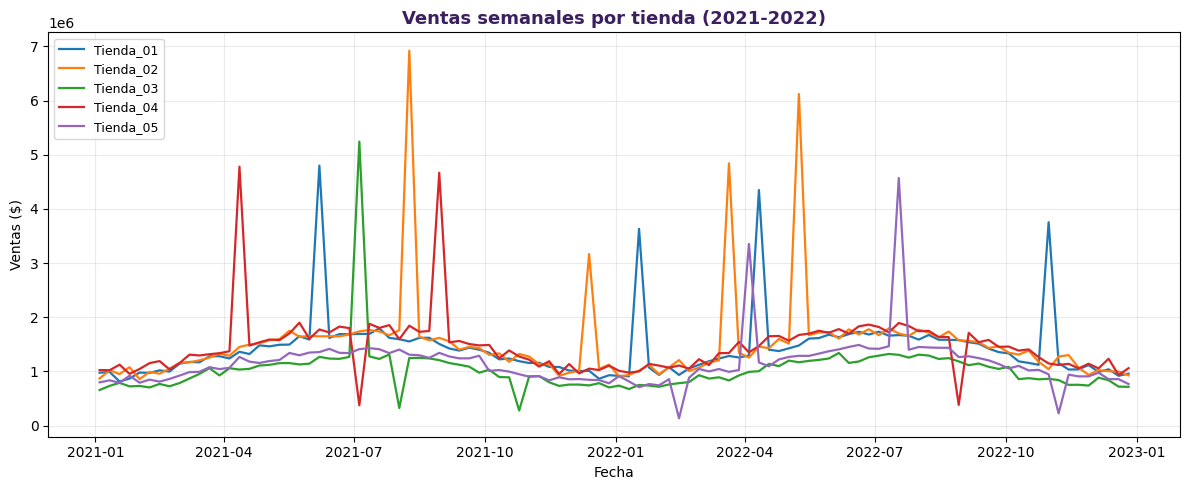

INTERPRETACION:
Si miran con cuidado, algunas tiendas tienen picos o caidas muy bruscas que rompen el patron
normal de la linea. Esos son justamente los candidatos a ser anomalias: semanas que un gerente
de tienda querria revisar antes que nadie, porque ahi es donde esta el riesgo o la oportunidad.
Nuestro trabajo de hoy es encontrarlas de forma automatica, sin mirar el grafico tienda por tienda.


In [6]:
# Celda 4b: grafiquemos la serie de ventas de todas las tiendas juntas para ver el panorama completo.

plt.figure(figsize=(12, 5))
for tienda in df["Tienda"].unique():
    sub = df[df["Tienda"] == tienda]
    plt.plot(sub["Fecha"], sub["Ventas"], label=tienda, linewidth=1.6)

plt.title("Ventas semanales por tienda (2021-2022)", fontsize=13, fontweight="bold", color=COLOR_MORADO)
plt.xlabel("Fecha")
plt.ylabel("Ventas ($)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print("Si miran con cuidado, algunas tiendas tienen picos o caidas muy bruscas que rompen el patron")
print("normal de la linea. Esos son justamente los candidatos a ser anomalias: semanas que un gerente")
print("de tienda querria revisar antes que nadie, porque ahi es donde esta el riesgo o la oportunidad.")
print("Nuestro trabajo de hoy es encontrarlas de forma automatica, sin mirar el grafico tienda por tienda.")


## Celda 5 — Preparar las variables y escalarlas

In [7]:
# Celda 5: seleccionamos las variables numericas que vamos a usar para detectar anomalias
# y las escalamos con StandardScaler (deja cada variable con media 0 y desviacion estandar 1).

features = ["Ventas", "Temperatura", "Precio_Combustible", "CPI", "Desempleo"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables usadas:", features)
print()
print("ANTES de escalar (primeras 3 filas):")
print(X.head(3).to_string(index=False))
print()
print("DESPUES de escalar (primeras 3 filas):")
print(pd.DataFrame(X_scaled, columns=features).head(3).round(2).to_string(index=False))
print()
print("INTERPRETACION:")
print("Noten que antes, 'Ventas' tenia numeros de 6 cifras y 'Desempleo' numeros de una sola cifra.")
print("Despues de escalar, todas las variables quedan en una escala comparable (cerca de -3 a 3).")
print("Asi ningun algoritmo va a pensar que 'Ventas' es mas importante solo por tener numeros mas grandes.")


Variables usadas: ['Ventas', 'Temperatura', 'Precio_Combustible', 'CPI', 'Desempleo']

ANTES de escalar (primeras 3 filas):
   Ventas  Temperatura  Precio_Combustible   CPI  Desempleo
974914.89         20.9               3.372 210.5       8.48
990182.61         22.1               3.271 210.0       8.83
812368.79         24.0               3.347 210.4       8.50

DESPUES de escalar (primeras 3 filas):
 Ventas  Temperatura  Precio_Combustible   CPI  Desempleo
  -0.53        -0.33                0.56 -1.60       1.29
  -0.50         0.06               -0.25 -1.69       2.19
  -0.78         0.67                0.36 -1.62       1.34

INTERPRETACION:
Noten que antes, 'Ventas' tenia numeros de 6 cifras y 'Desempleo' numeros de una sola cifra.
Despues de escalar, todas las variables quedan en una escala comparable (cerca de -3 a 3).
Asi ningun algoritmo va a pensar que 'Ventas' es mas importante solo por tener numeros mas grandes.


## Celda 6 — Algoritmo 1: K-Means

K-Means agrupa las semanas en "clusters" segun que tan parecidas son entre si. Una semana que
queda muy lejos del centro de su propio grupo es sospechosa de ser una anomalia.

Primero usamos el **Grafico del Codo** para decidir cuantos grupos (k) tiene sentido usar.


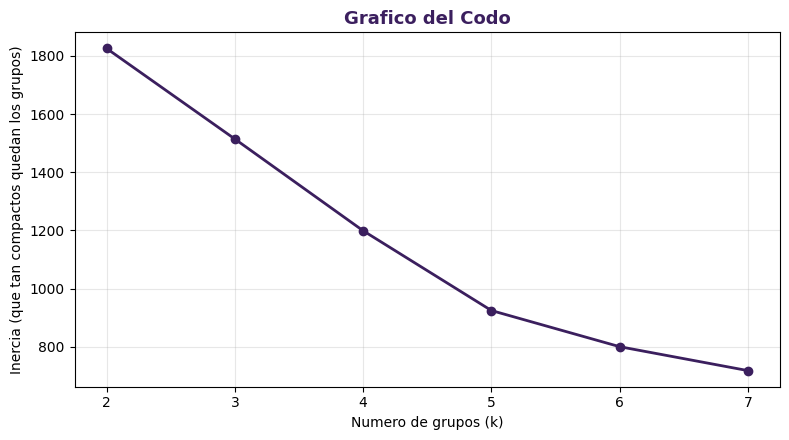

INTERPRETACION:
Buscamos el punto donde la linea deja de bajar tan rapido (el 'codo'). Despues de ese punto,
agregar mas grupos ya no mejora mucho las cosas. Con este dataset, k=3 suele ser un buen balance:
un grupo de ventas bajas, uno de ventas normales/altas, y uno de comportamientos raros.


In [8]:
# Celda 6a: Grafico del Codo. Probamos varios valores de k y vemos donde deja de mejorar mucho.

inercias = []
valores_k = range(2, 8)
for k in valores_k:
    km_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_prueba.fit(X_scaled)
    inercias.append(km_prueba.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(list(valores_k), inercias, marker="o", color=COLOR_MORADO, linewidth=2)
plt.title("Grafico del Codo", fontsize=13, fontweight="bold", color=COLOR_MORADO)
plt.xlabel("Numero de grupos (k)")
plt.ylabel("Inercia (que tan compactos quedan los grupos)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print("Buscamos el punto donde la linea deja de bajar tan rapido (el 'codo'). Despues de ese punto,")
print("agregar mas grupos ya no mejora mucho las cosas. Con este dataset, k=3 suele ser un buen balance:")
print("un grupo de ventas bajas, uno de ventas normales/altas, y uno de comportamientos raros.")


In [9]:
# Celda 6b: entrenamos K-Means con k=3 y medimos que tan bien separados quedan los grupos.

k_elegido = 3
kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, clusters)

# Anomalia = distancia al centro de su propio cluster, tomamos el 5% mas lejano
distancias = np.min(kmeans.transform(X_scaled), axis=1)
umbral_kmeans = np.percentile(distancias, 95)
df["anomalia_kmeans"] = (distancias > umbral_kmeans).astype(int)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Semanas marcadas como anomalia por K-Means: {df['anomalia_kmeans'].sum()}")
print()
print("INTERPRETACION:")
print(f"- El Silhouette Score va de -1 a 1. Un valor de {sil_score:.2f} indica grupos ", end="")
print("razonablemente bien separados." if sil_score > 0.25 else "grupos con bastante solapamiento.")
print("- Marcamos como anomalia el 5% de semanas que quedaron mas lejos del centro de su grupo.")
print("- K-Means asume que los grupos son mas o menos redondos, por eso a veces se le escapan")
print("  anomalias con formas raras. Vamos a comparar con otros algoritmos para ver si coinciden.")


Silhouette Score: 0.277
Semanas marcadas como anomalia por K-Means: 26

INTERPRETACION:
- El Silhouette Score va de -1 a 1. Un valor de 0.28 indica grupos razonablemente bien separados.
- Marcamos como anomalia el 5% de semanas que quedaron mas lejos del centro de su grupo.
- K-Means asume que los grupos son mas o menos redondos, por eso a veces se le escapan
  anomalias con formas raras. Vamos a comparar con otros algoritmos para ver si coinciden.


## Celda 7 — Algoritmo 2: DBSCAN

DBSCAN agrupa por **densidad**: si hay muchos puntos apretados en una zona, es un grupo normal.
Un punto solo, sin vecinos cercanos, se marca directamente como anomalia.


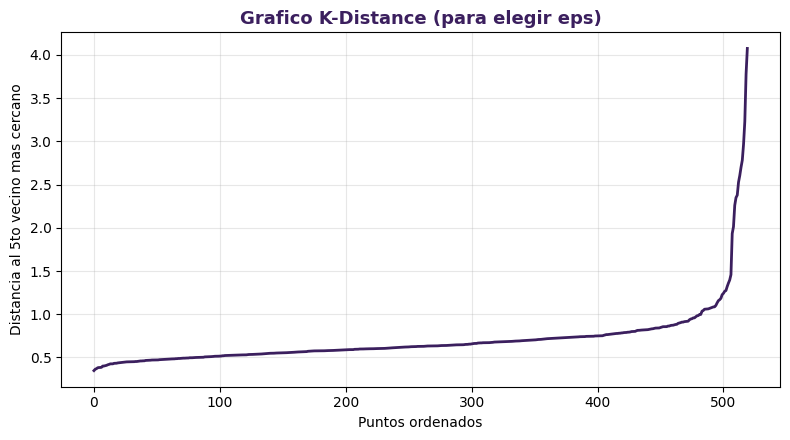

INTERPRETACION:
Buscamos el punto donde la curva 'se dispara' hacia arriba (el codo de esta curva).
Ese valor en el eje Y es un buen candidato para eps: los puntos con distancias mayores
a ese valor probablemente estan aislados, es decir, son anomalias.


In [10]:
# Celda 7a: Grafico K-Distance, nos ayuda a elegir el parametro eps (que tan cerca es "cerca").

from sklearn.neighbors import NearestNeighbors

vecinos = NearestNeighbors(n_neighbors=5)
vecinos_fit = vecinos.fit(X_scaled)
distancias_k, _ = vecinos_fit.kneighbors(X_scaled)
distancias_ordenadas = np.sort(distancias_k[:, -1])

plt.figure(figsize=(8, 4.5))
plt.plot(distancias_ordenadas, color=COLOR_MORADO, linewidth=2)
plt.title("Grafico K-Distance (para elegir eps)", fontsize=13, fontweight="bold", color=COLOR_MORADO)
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al 5to vecino mas cercano")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print("Buscamos el punto donde la curva 'se dispara' hacia arriba (el codo de esta curva).")
print("Ese valor en el eje Y es un buen candidato para eps: los puntos con distancias mayores")
print("a ese valor probablemente estan aislados, es decir, son anomalias.")


In [11]:
# Celda 7b: entrenamos DBSCAN. eps=1.2 fue elegido mirando el codo del grafico anterior.

dbscan = DBSCAN(eps=1.2, min_samples=5)
etiquetas_dbscan = dbscan.fit_predict(X_scaled)

# DBSCAN marca las anomalias directamente con la etiqueta -1
df["anomalia_dbscan"] = (etiquetas_dbscan == -1).astype(int)
n_grupos = len(set(etiquetas_dbscan)) - (1 if -1 in etiquetas_dbscan else 0)

print(f"Grupos encontrados por DBSCAN: {n_grupos}")
print(f"Semanas marcadas como anomalia por DBSCAN: {df['anomalia_dbscan'].sum()}")
print()
print("INTERPRETACION:")
print(f"- DBSCAN encontro {n_grupos} grupos de forma automatica, sin que le dijeramos cuantos esperar.")
print("- A diferencia de K-Means, DBSCAN puede encontrar grupos de formas raras, no solo redondas.")
print("- Si el numero de anomalias les parece muy alto o muy bajo, el parametro eps es el que hay")
print("  que ajustar: eps mas chico = mas anomalias, eps mas grande = menos anomalias.")


Grupos encontrados por DBSCAN: 1
Semanas marcadas como anomalia por DBSCAN: 15

INTERPRETACION:
- DBSCAN encontro 1 grupos de forma automatica, sin que le dijeramos cuantos esperar.
- A diferencia de K-Means, DBSCAN puede encontrar grupos de formas raras, no solo redondas.
- Si el numero de anomalias les parece muy alto o muy bajo, el parametro eps es el que hay
  que ajustar: eps mas chico = mas anomalias, eps mas grande = menos anomalias.


## Celda 8 — Algoritmo 3: Isolation Forest

Isolation Forest construye muchos arboles de decision al azar para "aislar" cada dato. Un dato
normal necesita muchos cortes para quedar aislado; uno anomalo, necesita pocos.


In [12]:
# Celda 8: entrenamos Isolation Forest. contamination=0.05 le dice al modelo que esperamos
# que un 5% de los datos sean anomalias (es un supuesto, se puede ajustar).

iso_forest = IsolationForest(contamination=0.05, random_state=42)
pred_iso = iso_forest.fit_predict(X_scaled)  # devuelve 1 (normal) o -1 (anomalia)
scores_iso = iso_forest.decision_function(X_scaled)  # entre mas negativo, mas anomalo

df["anomalia_isoforest"] = (pred_iso == -1).astype(int)
df["score_isoforest"] = scores_iso

print(f"Semanas marcadas como anomalia por Isolation Forest: {df['anomalia_isoforest'].sum()}")
print()
print("Las 5 semanas con el score MAS negativo (las mas anomalas segun este algoritmo):")
display(df.nsmallest(5, "score_isoforest")[["Tienda", "Fecha", "Ventas", "score_isoforest"]])

print()
print("INTERPRETACION:")
print("El anomaly score no es una probabilidad, es una medida relativa: entre mas negativo,")
print("menos cortes necesito el arbol para aislar ese dato, y por lo tanto mas raro es.")
print("Revisen la columna Ventas de esas 5 semanas: probablemente son picos o caidas muy marcadas")
print("comparadas con el promedio de su tienda. Para el negocio, cada una de estas filas es un caso")
print("puntual que valdria la pena revisar: ¿fue un error de registro, una promocion, o una perdida real?")


Semanas marcadas como anomalia por Isolation Forest: 26

Las 5 semanas con el score MAS negativo (las mas anomalas segun este algoritmo):


,Tienda,Fecha,Ventas,score_isoforest
234,Tienda_03,2021-07-05,5242823.42,-0.120083
135,Tienda_02,2021-08-09,6920149.53,-0.119748
167,Tienda_02,2022-03-21,4840603.69,-0.112469
326,Tienda_04,2021-04-12,4778986.13,-0.087804
22,Tienda_01,2021-06-07,4799318.05,-0.075905



INTERPRETACION:
El anomaly score no es una probabilidad, es una medida relativa: entre mas negativo,
menos cortes necesito el arbol para aislar ese dato, y por lo tanto mas raro es.
Revisen la columna Ventas de esas 5 semanas: probablemente son picos o caidas muy marcadas
comparadas con el promedio de su tienda. Para el negocio, cada una de estas filas es un caso
puntual que valdria la pena revisar: ¿fue un error de registro, una promocion, o una perdida real?


## Celda 9 — Algoritmo 4: One-Class SVM

One-Class SVM dibuja una frontera alrededor de lo que consideramos "zona normal", usando un
kernel RBF (una curva flexible). Todo lo que cae afuera de esa frontera es anomalia.


In [13]:
# Celda 9: entrenamos One-Class SVM. nu=0.05 es similar a contamination: el % esperado de anomalias.

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
pred_ocsvm = ocsvm.fit_predict(X_scaled)

df["anomalia_ocsvm"] = (pred_ocsvm == -1).astype(int)

print(f"Semanas marcadas como anomalia por One-Class SVM: {df['anomalia_ocsvm'].sum()}")
print()
print("INTERPRETACION:")
print("One-Class SVM trazo una frontera flexible alrededor de la 'nube' de semanas normales.")
print("Cualquier semana que cayo fuera de esa frontera quedo marcada como anomalia.")
print("Es el algoritmo mas lento de los cuatro, pero con un dataset de este tamano no se nota.")


Semanas marcadas como anomalia por One-Class SVM: 20

INTERPRETACION:
One-Class SVM trazo una frontera flexible alrededor de la 'nube' de semanas normales.
Cualquier semana que cayo fuera de esa frontera quedo marcada como anomalia.
Es el algoritmo mas lento de los cuatro, pero con un dataset de este tamano no se nota.


## Celda 10 — ¿Cual algoritmo lo hizo mejor? Comparando con Precision, Recall y F1-Score

Aqui usamos la columna `Anomalia_Real` (la que "escondimos" al principio) para calificar a cada
algoritmo. En la vida real casi nunca tenemos esta columna de antemano, pero para aprender hoy
nos sirve muchisimo tenerla.


In [14]:
# Celda 10: calculamos Precision, Recall y F1-Score de cada algoritmo contra la realidad.

algoritmos = {
    "K-Means": "anomalia_kmeans",
    "DBSCAN": "anomalia_dbscan",
    "Isolation Forest": "anomalia_isoforest",
    "One-Class SVM": "anomalia_ocsvm",
}

resultados = []
for nombre, columna in algoritmos.items():
    y_real = df["Anomalia_Real"]
    y_pred = df[columna]
    p = precision_score(y_real, y_pred, zero_division=0)
    r = recall_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)
    resultados.append({"Algoritmo": nombre, "Precision": round(p, 3), "Recall": round(r, 3), "F1-Score": round(f1, 3)})

tabla_resultados = pd.DataFrame(resultados)
print("TABLA COMPARATIVA DE LOS 4 ALGORITMOS")
print("=" * 60)
display(tabla_resultados)

mejor = tabla_resultados.loc[tabla_resultados["F1-Score"].idxmax(), "Algoritmo"]
print()
print("INTERPRETACION:")
print(f"- Segun el F1-Score, el algoritmo que mejor equilibrio logro fue: {mejor}")
print("- Precision alta significa que cuando el algoritmo dice 'anomalia', casi siempre acierta.")
print("- Recall alto significa que el algoritmo encontro la mayoria de las anomalias reales que existian.")
print("- Si un algoritmo tiene Precision alta pero Recall bajo, esta siendo 'desconfiado':")
print("  marca pocas cosas, pero las que marca casi siempre son correctas.")
print()
print("LECTURA DE NEGOCIO:")
print("- Si a la empresa le preocupa perder tiempo revisando falsas alarmas, conviene priorizar Precision.")
print("- Si a la empresa le preocupa dejar pasar una anomalia real (por ejemplo, un fraude o una perdida")
print("  grande), conviene priorizar Recall, aunque eso implique revisar mas casos de mas.")
print("- El F1-Score es la opcion segura cuando ambos errores (falsas alarmas y anomalias no detectadas)")
print("  cuestan caro por igual, y no se quiere sacrificar uno por el otro.")


TABLA COMPARATIVA DE LOS 4 ALGORITMOS


,Algoritmo,Precision,Recall,F1-Score
0,K-Means,0.577,0.789,0.667
1,DBSCAN,1.000,0.789,0.882
2,Isolation Forest,0.538,0.737,0.622
3,One-Class SVM,0.500,0.526,0.513


INTERPRETACION:
- Segun el F1-Score, el algoritmo que mejor equilibrio logro fue: DBSCAN
- Precision alta significa que cuando el algoritmo dice 'anomalia', casi siempre acierta.
- Recall alto significa que el algoritmo encontro la mayoria de las anomalias reales que existian.
- Si un algoritmo tiene Precision alta pero Recall bajo, esta siendo 'desconfiado':
  marca pocas cosas, pero las que marca casi siempre son correctas.

LECTURA DE NEGOCIO:
- Si a la empresa le preocupa perder tiempo revisando falsas alarmas, conviene priorizar Precision.
- Si a la empresa le preocupa dejar pasar una anomalia real (por ejemplo, un fraude o una perdida
  grande), conviene priorizar Recall, aunque eso implique revisar mas casos de mas.
- El F1-Score es la opcion segura cuando ambos errores (falsas alarmas y anomalias no detectadas)
  cuestan caro por igual, y no se quiere sacrificar uno por el otro.


## Celda 11 — Consenso por votación

Si varios algoritmos coinciden en que una semana es rara, confiamos mas en esa alerta que si
solo uno la marco.


In [15]:
# Celda 11: sumamos cuantos de los 4 algoritmos marcaron cada semana como anomalia.

df["votos_anomalia"] = (
    df["anomalia_kmeans"] + df["anomalia_dbscan"] + df["anomalia_isoforest"] + df["anomalia_ocsvm"]
)

# Consenso: al menos 3 de los 4 algoritmos coinciden
df["anomalia_consenso"] = (df["votos_anomalia"] >= 3).astype(int)

print("Distribucion de votos (cuantos algoritmos marcaron cada semana):")
print(df["votos_anomalia"].value_counts().sort_index())
print()
print(f"Semanas con CONSENSO (3 o 4 algoritmos de acuerdo): {df['anomalia_consenso'].sum()}")
print()
display(df[df["anomalia_consenso"] == 1][["Tienda", "Fecha", "Ventas", "votos_anomalia", "Anomalia_Real"]])

print()
print("INTERPRETACION:")
print("Estas son las semanas donde varios algoritmos, mirando el problema desde angulos distintos,")
print("llegaron a la misma conclusion. Comparen la columna 'Anomalia_Real' con estas filas:")
print("si coincide casi siempre, el consenso esta funcionando muy bien como filtro de falsos positivos.")


Distribucion de votos (cuantos algoritmos marcaron cada semana):
votos_anomalia
0    477
1     21
2      7
3      8
4      7
Name: count, dtype: int64

Semanas con CONSENSO (3 o 4 algoritmos de acuerdo): 15



,Tienda,Fecha,Ventas,votos_anomalia,Anomalia_Real
22,Tienda_01,2021-06-07,4799318.05,3,1
54,Tienda_01,2022-01-17,3631954.86,3,1
66,Tienda_01,2022-04-11,4348072.75,3,1
86,Tienda_01,2022-08-29,1578769.74,3,0
95,Tienda_01,2022-10-31,3754472.87,3,1
135,Tienda_02,2021-08-09,6920149.53,4,1
167,Tienda_02,2022-03-21,4840603.69,4,1
174,Tienda_02,2022-05-09,6119808.33,4,1
234,Tienda_03,2021-07-05,5242823.42,4,1
238,Tienda_03,2021-08-02,323793.39,3,1



INTERPRETACION:
Estas son las semanas donde varios algoritmos, mirando el problema desde angulos distintos,
llegaron a la misma conclusion. Comparen la columna 'Anomalia_Real' con estas filas:
si coincide casi siempre, el consenso esta funcionando muy bien como filtro de falsos positivos.


## Celda 12 — Visualizacion con PCA en 2 dimensiones

Tenemos 5 variables, imposible verlas todas juntas. PCA las combina en 2 ejes resumen para
poder dibujar un mapa.


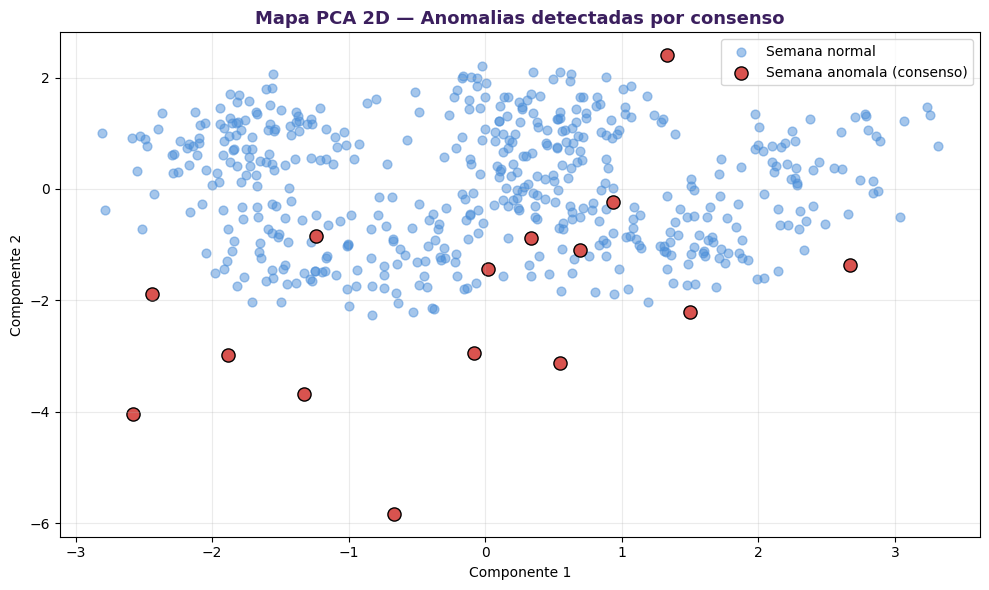

INTERPRETACION:
Estos 2 componentes explican el 67.5% de la informacion original de las 5 variables.
Los puntos rojos son las semanas anomalas por consenso. Si estan alejados de la nube azul,
es una buena senal: significa que el mapa 2D SI logra capturar lo que hace raras a esas semanas.

LECTURA DE NEGOCIO:
Si los puntos rojos aparecen todos juntos, formando su propio grupo, probablemente comparten
una misma causa de fondo (por ejemplo, todas ocurrieron en fin de ano o en tiendas similares),
y ahi la empresa podria atacar una sola causa raiz. Si aparecen dispersos por todo el mapa,
cada anomalia responde a un motivo distinto, y hay que revisarlas una por una.


In [16]:
# Celda 12: reducimos las 5 variables a 2 componentes principales y graficamos.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(10, 6))
normales = df["anomalia_consenso"] == 0
anomalas = df["anomalia_consenso"] == 1

plt.scatter(X_pca[normales, 0], X_pca[normales, 1], c=COLOR_AZUL, alpha=0.5, label="Semana normal", s=40)
plt.scatter(X_pca[anomalas, 0], X_pca[anomalas, 1], c=COLOR_ROJO, label="Semana anomala (consenso)", s=90, edgecolors="black")

plt.title("Mapa PCA 2D — Anomalias detectadas por consenso", fontsize=13, fontweight="bold", color=COLOR_MORADO)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print(f"Estos 2 componentes explican el {varianza_explicada*100:.1f}% de la informacion original de las 5 variables.")
print("Los puntos rojos son las semanas anomalas por consenso. Si estan alejados de la nube azul,")
print("es una buena senal: significa que el mapa 2D SI logra capturar lo que hace raras a esas semanas.")
print()
print("LECTURA DE NEGOCIO:")
print("Si los puntos rojos aparecen todos juntos, formando su propio grupo, probablemente comparten")
print("una misma causa de fondo (por ejemplo, todas ocurrieron en fin de ano o en tiendas similares),")
print("y ahi la empresa podria atacar una sola causa raiz. Si aparecen dispersos por todo el mapa,")
print("cada anomalia responde a un motivo distinto, y hay que revisarlas una por una.")


## Celda 13 — Repaso rapido: series temporales avanzadas (ADF, ACF, PACF)

Para cerrar, repasamos 3 herramientas que ya usaron en la actividad de El Roble la semana
pasada, esta vez con la serie de ventas totales (todas las tiendas juntas, sumadas por semana).


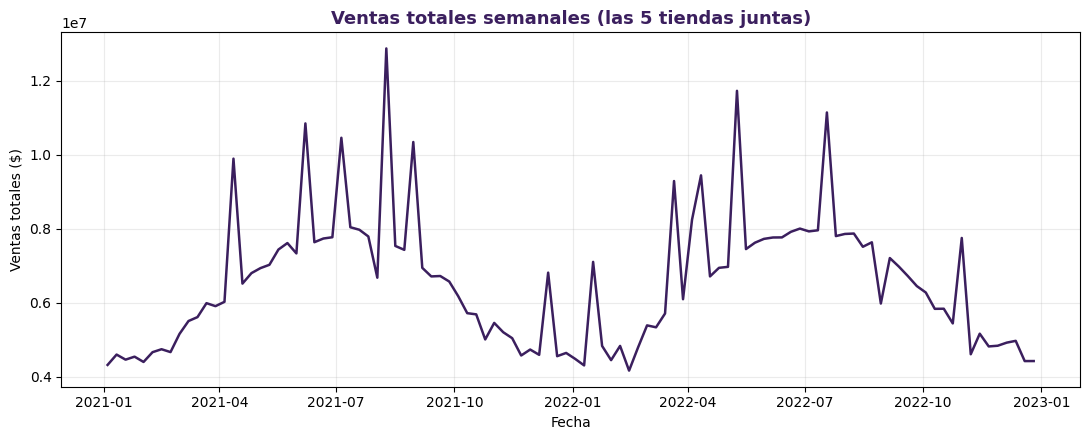

INTERPRETACION:
Esta serie combina el comportamiento de las 5 tiendas. Se nota una tendencia de crecimiento
y una estacionalidad (picos hacia fin de ano). Antes de modelarla con ARIMA, como hicieron
en El Roble, necesitamos revisar si es estacionaria.


In [17]:
# Celda 13a: construimos la serie de ventas TOTALES (todas las tiendas sumadas) por semana.

ventas_totales = df.groupby("Fecha")["Ventas"].sum().sort_index()

plt.figure(figsize=(11, 4.5))
plt.plot(ventas_totales.index, ventas_totales.values, color=COLOR_MORADO, linewidth=1.8)
plt.title("Ventas totales semanales (las 5 tiendas juntas)", fontsize=13, fontweight="bold", color=COLOR_MORADO)
plt.xlabel("Fecha")
plt.ylabel("Ventas totales ($)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print("Esta serie combina el comportamiento de las 5 tiendas. Se nota una tendencia de crecimiento")
print("y una estacionalidad (picos hacia fin de ano). Antes de modelarla con ARIMA, como hicieron")
print("en El Roble, necesitamos revisar si es estacionaria.")


In [18]:
# Celda 13b: prueba ADF (Augmented Dickey-Fuller) de estacionariedad.

resultado_adf = adfuller(ventas_totales.dropna())
estadistico = resultado_adf[0]
p_value = resultado_adf[1]
es_estacionaria = p_value < 0.05

print("PRUEBA ADF")
print("=" * 50)
print(f"Estadistico ADF: {estadistico:.4f}")
print(f"p-value:         {p_value:.4f}")
print()
print("INTERPRETACION:")
print("H0 (hipotesis nula): la serie NO es estacionaria.")
if es_estacionaria:
    print(f"Como el p-value ({p_value:.4f}) es MENOR a 0.05, rechazamos H0.")
    print("Conclusion: la serie SI es estacionaria. Podemos modelarla directamente.")
else:
    print(f"Como el p-value ({p_value:.4f}) es MAYOR a 0.05, NO rechazamos H0.")
    print("Conclusion: la serie NO es estacionaria. Habria que diferenciarla antes de usar ARIMA,")
    print("igual que hicieron algunas salas en la actividad de El Roble.")


PRUEBA ADF
Estadistico ADF: -2.1495
p-value:         0.2251

INTERPRETACION:
H0 (hipotesis nula): la serie NO es estacionaria.
Como el p-value (0.2251) es MAYOR a 0.05, NO rechazamos H0.
Conclusion: la serie NO es estacionaria. Habria que diferenciarla antes de usar ARIMA,
igual que hicieron algunas salas en la actividad de El Roble.


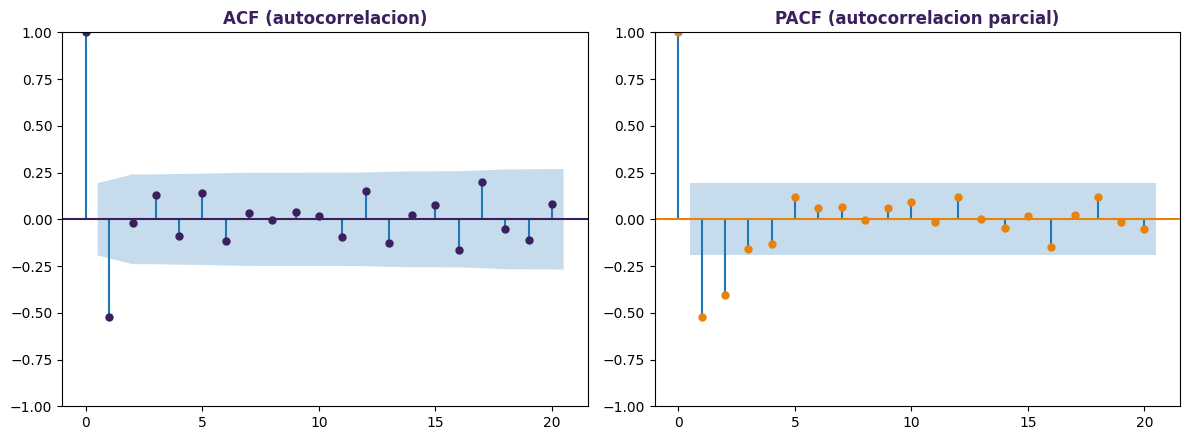

INTERPRETACION:
En el grafico ACF (izquierda), miren en que lag las barras dejan de salirse de la zona sombreada:
esa es una pista del parametro q.
En el grafico PACF (derecha), hagan lo mismo: esa es una pista del parametro p.
Este es exactamente el mismo criterio que usaron en El Roble para elegir su modelo ARIMA,
solo que alli lo hizo automaticamente la tabla de AIC del notebook.


In [19]:
# Celda 13c: graficos ACF y PACF, para elegir los parametros p y q de un futuro modelo ARIMA.

serie_para_graficos = ventas_totales.diff().dropna() if not es_estacionaria else ventas_totales

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
plot_acf(serie_para_graficos, ax=ax1, lags=20, color=COLOR_MORADO)
ax1.set_title("ACF (autocorrelacion)", fontsize=12, fontweight="bold", color=COLOR_MORADO)
plot_pacf(serie_para_graficos, ax=ax2, lags=20, color=COLOR_NARANJA, method="ywm")
ax2.set_title("PACF (autocorrelacion parcial)", fontsize=12, fontweight="bold", color=COLOR_MORADO)
plt.tight_layout()
plt.show()

print("INTERPRETACION:")
print("En el grafico ACF (izquierda), miren en que lag las barras dejan de salirse de la zona sombreada:")
print("esa es una pista del parametro q.")
print("En el grafico PACF (derecha), hagan lo mismo: esa es una pista del parametro p.")
print("Este es exactamente el mismo criterio que usaron en El Roble para elegir su modelo ARIMA,")
print("solo que alli lo hizo automaticamente la tabla de AIC del notebook.")


## Celda 14 — Resumen ejecutivo del taller de hoy

In [20]:
# Celda 14: resumen automatico de todo lo que hicimos, util para su bitacora del II Avance.

print("=" * 65)
print("RESUMEN EJECUTIVO — TALLER DE DETECCION DE ANOMALIAS")
print("=" * 65)
print(f"Filas analizadas:                {len(df):,}")
print(f"Tiendas:                          {df['Tienda'].nunique()}")
print(f"Anomalias reales (ground truth):  {df['Anomalia_Real'].sum()}")
print()
print("Anomalias detectadas por algoritmo:")
for nombre, columna in algoritmos.items():
    print(f"  - {nombre:<20}: {df[columna].sum()} semanas")
print(f"  - {'Consenso (>=3 de 4)':<20}: {df['anomalia_consenso'].sum()} semanas")
print()
print(f"Mejor algoritmo segun F1-Score:   {mejor}")
print(f"Serie de ventas totales estacionaria (ADF):  {'Si' if es_estacionaria else 'No'}")
print("=" * 65)


RESUMEN EJECUTIVO — TALLER DE DETECCION DE ANOMALIAS
Filas analizadas:                520
Tiendas:                          5
Anomalias reales (ground truth):  19

Anomalias detectadas por algoritmo:


  - K-Means             : 26 semanas
  - DBSCAN              : 15 semanas
  - Isolation Forest    : 26 semanas
  - One-Class SVM       : 20 semanas
  - Consenso (>=3 de 4) : 15 semanas

Mejor algoritmo segun F1-Score:   DBSCAN
Serie de ventas totales estacionaria (ADF):  No


## Celda 15 — Lectura de negocio: ¿que haria la empresa con esto?

Con los resultados que ya generamos en este notebook, cerramos conectando cada pieza con una
decision real de negocio. Esto lo repasamos juntos en clase, apoyandonos en los numeros que ya
tenemos en pantalla:

1. **¿Que algoritmo usaria la empresa?** Con la tabla comparativa de Precision, Recall y F1-Score
   ya calculada arriba, la eleccion depende de que error le cuesta mas caro a la empresa: perseguir
   falsas alarmas, o dejar pasar una anomalia real.

2. **¿Que hacer con las semanas de consenso?** Las semanas donde 3 o 4 algoritmos coincidieron son
   las que un analista deberia revisar primero: ahi esta concentrado el riesgo o la oportunidad
   mas confiable de todo el dataset.

3. **¿Que dice el mapa PCA sobre la causa raiz?** Si las anomalias aparecen agrupadas, sugiere una
   causa comun (temporada, tipo de tienda, region) que la empresa podria atacar de una sola vez.
   Si aparecen dispersas, cada caso necesita revisión individual.

4. **¿Como se conecta esto con el Proyecto?** El mismo flujo de hoy (escalar variables, aplicar
   varios algoritmos, comparar con metricas, visualizar con PCA) es exactamente lo que se espera
   ver en los resultados preliminares del **II Avance del Proyecto**, aplicado al dataset propio
   de cada equipo.


---
## Cierre

Con este notebook ya se aplico, de principio a fin, el flujo completo de deteccion de anomalias:

- Los 4 algoritmos corridos y comparados con metricas reales (Precision, Recall, F1-Score)
- El consenso por votacion entre modelos, para filtrar falsas alarmas
- Un mapa PCA 2D para visualizar las anomalias
- Un repaso de ADF, ACF y PACF, conectado directamente con lo que ya se hizo en El Roble

Recuerden: el **II Avance del Proyecto** se entrega al finalizar este modulo, e incluye
resultados preliminares con visualizaciones e interpretacion de negocio — exactamente el tipo
de flujo que acabamos de recorrer aqui, aplicado ahora al dataset propio de cada equipo.


## Celda 16 — Preguntas de interpretacion y razonamiento

Estas preguntas se responden **con los resultados que ya tenemos en pantalla**, aplicando la
teoria que vimos hoy. No es investigar nada por fuera, es leer los numeros de nuestro propio
notebook y razonar con ellos, igual que lo haria un analista dentro de una empresa.


In [21]:
# Celda 16: dejamos a la vista, en un solo lugar, los numeros exactos que vamos a usar
# para razonar las preguntas de abajo. No hay que buscar nada mas, ya esta todo aqui.

print("NUMEROS DE REFERENCIA PARA LAS PREGUNTAS")
print("=" * 60)
display(tabla_resultados)
print()
print(f"Semanas con consenso (3 o 4 algoritmos de acuerdo): {df['anomalia_consenso'].sum()}")
print(f"Varianza explicada por los 2 componentes de PCA:    {varianza_explicada*100:.1f}%")
print(f"Resultado de la prueba ADF sobre ventas totales:    p-value = {p_value:.4f}  ->  ", end="")
print("estacionaria" if es_estacionaria else "NO estacionaria")


NUMEROS DE REFERENCIA PARA LAS PREGUNTAS


,Algoritmo,Precision,Recall,F1-Score
0,K-Means,0.577,0.789,0.667
1,DBSCAN,1.000,0.789,0.882
2,Isolation Forest,0.538,0.737,0.622
3,One-Class SVM,0.500,0.526,0.513



Semanas con consenso (3 o 4 algoritmos de acuerdo): 15
Varianza explicada por los 2 componentes de PCA:    67.5%
Resultado de la prueba ADF sobre ventas totales:    p-value = 0.2251  ->  NO estacionaria


**Pregunta 1 — Comparacion de algoritmos (teoria aplicada a K-Means, DBSCAN, Isolation Forest
y One-Class SVM).**
Miren la tabla de Precision, Recall y F1-Score de arriba. ¿Cual algoritmo tuvo el F1-Score mas
alto en NUESTRA corrida? Con la definicion de Precision y Recall que vimos en clase, expliquen
en sus propias palabras por que ese algoritmo quedo primero y no otro.

**Pregunta 2 — Precision vs. Recall, aplicado a una decision real.**
Si esta empresa decidiera priorizar Recall por encima de Precision (para no dejar pasar ninguna
anomalia real, aunque revisen mas falsas alarmas), ¿cual de los 4 algoritmos de la tabla
recomendarian usar? Justifiquen con el numero exacto de Recall de ese algoritmo.

**Pregunta 3 — Consenso por votacion.**
Anotamos arriba cuantas semanas quedaron marcadas por consenso (3 o 4 algoritmos de acuerdo).
Con la logica de consenso que explicamos en clase, ¿por que estas semanas son las que un
analista deberia revisar PRIMERO, antes que las que solo un algoritmo marco?

**Pregunta 4 — Lectura del mapa PCA.**
Vuelvan a mirar el grafico de PCA de la Celda 12. ¿Los puntos rojos (anomalias) aparecen
agrupados entre si, o dispersos por todo el mapa? Con lo que vimos sobre que hace PCA, expliquen
que significaria cada uno de esos dos escenarios para una empresa que quiere entender la CAUSA
de sus anomalias, no solo encontrarlas.

**Pregunta 5 — Series temporales avanzadas, conectado con El Roble.**
El resultado de la prueba ADF sobre las ventas totales quedo anotado arriba (estacionaria o no).
Con la logica de H0 y p-value que repasamos en clase, expliquen que significa ese resultado, y
si tuvieran que modelar esta serie con ARIMA como en El Roble, ¿que harian antes de elegir
(p, d, q)?

**Pregunta 6 — Conexion directa con el Proyecto (II Avance).**
Pensando en el dataset de su propio proyecto grupal: si aplicaran este mismo flujo (escalar
variables, correr varios algoritmos, comparar con F1-Score, revisar consenso y visualizar con
PCA), ¿que variables de su dataset usarian como equivalentes a Ventas, Temperatura, CPI, etc.?
